<a href="https://colab.research.google.com/github/ArtNizh/ML/blob/main/ML_%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 9. Рекуррентные сети и трансформеры: архитектуры для последовательностей и текста

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 7**


**Вариант / seed:** _номер варианта или значение SEED_


### Таблица вариантов

| Вариант | `SEED` | `D_MODEL` | `N_MAX` (пар в обучении) | `D_CELL` | Температуры для части H |
|---|---|---|---|---|---|
| 1 | 42 | 64 | 12 | 48 | 0.5 / 1.0 / 1.5 |
| 2 | 7 | 48 | 10 | 40 | 0.4 / 1.0 / 1.6 |
| 3 | 123 | 64 | 8 | 48 | 0.6 / 1.0 / 1.4 |
| 4 | 2024 | 56 | 12 | 56 | 0.5 / 1.2 / 1.8 |
| 5 | 314 | 48 | 8 | 40 | 0.7 / 1.0 / 1.3 |
| 6 | 555 | 64 | 10 | 56 | 0.5 / 0.9 / 1.7 |

> Вариант выдаёт преподаватель. Все числа в отчёте должны соответствовать **вашему** варианту,
> а не значениям из примера в тексте.

### Цель работы

Экспериментально установить, чем механизм внимания отличается от рекуррентного накопления состояния,
какой ценой достигается каждое из свойств (точность вспоминания, стоимость контекста, память при
генерации), и какие архитектурные свойства становятся поверхностью атаки на языковые модели.

### Задачи

1. Реализовать BPE-токенизацию и оценить влияние уровня токенизации на длину последовательности.
2. Измерить затухание градиента в рекуррентной сети и сравнить мультипликативный путь с аддитивным.
3. Реализовать масштабированное скалярное внимание с каузальной маской.
4. Проверить численно, что RoPE зависит только от разности позиций, и построить штраф ALiBi.
5. Обучить двухслойный мини-трансформер задаче ассоциативного вспоминания и найти индукционную голову.
6. Реализовать линейное внимание в рекуррентной форме и сравнить его с softmax-вниманием.
7. Сделать рекуррентную ячейку избирательной и проверить, что это даёт управляемую память.
8. Реализовать top-k и top-p отсечение и оценить статистику многих попыток генерации.

### Порядок выполнения

1. Выполните ячейку настройки среды и впишите параметры своего варианта.
2. Идите по частям A–H подряд, заполняя каждый блок `TODO`.
3. После каждой части ответьте на вопрос в конце этой части (ячейка Markdown «Ответ»).
4. Заполните таблицы отчёта и сформулируйте выводы.
5. Перед сдачей выполните Kernel → Restart & Run All и убедитесь, что ошибок нет.

### Ограничение по безопасности

Работа не содержит и не должна содержать кода атак на реальные языковые модели и сервисы,
готовых строк обхода ограничений или инструментов автоматического подбора вредоносных запросов.
Часть H исследует **статистику выборки и архитектурные предпосылки** уязвимостей на игрушечной
модели — этого достаточно для понимания следующей лекции.

In [ ]:
# Настройка окружения и единый стиль рисунков
import math, time, warnings
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore")
torch.set_num_threads(2)

PALETTE = {"attn": "#2E86AB", "linear": "#F2A541", "bad": "#D6455F",
           "good": "#3FA46A", "accent": "#7B4FA0", "gray": "#8A94A6"}
CMAP_HEAT = LinearSegmentedColormap.from_list(
    "heat7", ["#0B1D33", "#2E86AB", "#F2E8CF", "#F2A541", "#D6455F"])

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 10.5,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 10.5,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "--",
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})

def finish(fig, title=None):
    if title:
        fig.suptitle(title, fontsize=13, fontweight="bold", y=0.995)
    fig.tight_layout(rect=(0, 0, 1, 0.96 if title else 1.0))
    plt.show()

print("torch:", torch.__version__, "| потоков:", torch.get_num_threads())

torch: 2.11.0+cpu | потоков: 2


In [ ]:
# TODO 0: подставьте параметры СВОЕГО варианта из таблицы вариантов
SEED    = 314     # <-- ваш SEED
D_MODEL = 48      # <-- ваш D_MODEL
N_MAX   = 8      # <-- ваше число пар в обучении
D_CELL  = 40      # <-- ваша размерность рекуррентной ячейки
TAUS    = (0.7, 1.0, 1.3)   # <-- ваши температуры для части H

np.random.seed(SEED)
torch.manual_seed(SEED)
print("вариант: SEED=%d, D_MODEL=%d, N_MAX=%d, D_CELL=%d, TAUS=%s"
      % (SEED, D_MODEL, N_MAX, D_CELL, str(TAUS)))

вариант: SEED=314, D_MODEL=48, N_MAX=8, D_CELL=40, TAUS=(0.7, 1.0, 1.3)


## Часть A. Токенизация: BPE с нуля

Модель работает не с буквами и не со словами, а с токенами. Уровень токенизации задаёт длину
последовательности $n$, а значит и стоимость внимания $O(n^2)$, а также распределение частот:
редкие токены остаются недообученными.

**Задание A.1.** Реализуйте один шаг BPE: подсчёт частот пар соседних символов и слияние самой
частой пары.
**Задание A.2.** Обучите BPE на корпусе и измерьте коэффициенты сжатия «символы → BPE» и
«BPE → слова».
**Задание A.3.** Постройте график длины корпуса в токенах от числа выполненных слияний и
распределение частот токенов в логарифмических осях; отметьте порог редких токенов
`RARE_THR` (частота не выше `RARE_THR` за весь корпус).

Модель — это, в сущности, функция, которая принимает на вход последовательность целых чисел и выдаёт распределение вероятностей над следующими числами. Значит, текст надо как-то превратить в числа. Самый наивный способ — работать с отдельными символами: тогда словарь маленький (алфавит, знаки препинания), но последовательности получаются очень длинными. Другой крайний вариант — работать со словами целиком: последовательности короткие, но словарь раздувается до сотен тысяч, и редкие слова (опечатки, формы, имена) всё равно окажутся вне словаря.

**BPE (Byte Pair Encoding)**. Идея простая: начинаем с символов, потом склеиваем самые частые пары соседних символов в новый «токен» и повторяем много раз. Частые слова целиком становятся одним-двумя токенами, а редкие остаются разбитыми на кусочки. Так одновременно удерживаются и короткая длина последовательности, и умеренный словарь.

Пусть есть корпус, разбитый на слова. Каждое слово представим как последовательность символов с маркером конца слова `</w>`:

```
"модель" -> ('м', 'о', 'д', 'е', 'л', 'ь', '</w>')
```

Заведём словарь `vocab`, где ключ — это кортеж символов (текущее представление слова), а значение — сколько раз это слово встречается в корпусе. Например:

```
{('м','о','д','е','л','ь','</w>'): 6, ('т','о','к','е','н'): 3, ...}
```

На каждом шаге BPE делает три вещи:

1. **Считает частоты пар.** Для каждой пары соседних символов внутри каждого слова суммирует вес этого слова. Если слово `('м','о','д','е','л','ь','</w>')` встретилось 6 раз, то пары `('м','о')`, `('о','д')`, `('д','е')` и т.д. получают по +6 к своей частоте.
2. **Находит самую частую пару** — допустим, это `('д','е')`.
3. **Сливает её.** Во всех словах, где встречается `('д','е')`, эти два символа заменяются на один новый символ `'де'`. Словарь обновляется.

Шаги повторяются несколько раз. Каждое слияние уменьшает суммарную длину корпуса в токенах. Если на шаге было `L` токенов, а пара встречалась `c` раз, то после слияния станет `L - c` токенов.

In [ ]:
CORPUS = (
    "внимание позволяет модели обращаться к любой позиции последовательности напрямую. "
    "рекуррентная сеть накапливает состояние и постепенно теряет информацию о далёком прошлом. "
    "трансформер обучается параллельно по всем позициям и потому масштабируется. "
    "позиционное кодирование сообщает модели порядок токенов. "
    "линейное внимание заменяет матрицу внимания рекуррентным состоянием. "
    "избирательная рекуррентность делает затухание зависящим от входа. "
    "квантование и кэширование уменьшают стоимость генерации. "
) * 6

words = CORPUS.split()
vocab_words = {}
for w in words:
    # представляем слово как кортеж символов + маркер конца слова </w>
    key = tuple(w) + ("</w>",)
    vocab_words[key] = vocab_words.get(key, 0) + 1


def pair_counts(vocab):
    """Считает частоты всех пар соседних символов.

    Возвращает словарь {(символ1, символ2): суммарная частота}.
    Вес пары равен частоте слова, в котором она встретилась: если слово
    встретилось 6 раз, то каждая пара внутри него получает +6.
    """
    counts = {}
    for seq, freq in vocab.items():
        # идём по всем соседним позициям: (0,1), (1,2), ..., (n-2, n-1)
        for i in range(len(seq) - 1):
            pair = (seq[i], seq[i + 1])
            counts[pair] = counts.get(pair, 0) + freq
    return counts


def merge_pair(vocab, pair):
    """Склеивает все вхождения pair = (a, b) в один символ a+b.

    Возвращает новый словарь с той же структурой {кортеж_символов: частота}.
    Исходный словарь не изменяется.
    """
    a, b = pair
    merged = {}

    for seq, freq in vocab.items():
        new_seq = []          # новое представление слова
        i = 0
        n = len(seq)
        while i < n:
            # если текущий и следующий символы совпадают с искомой парой,
            # склеиваем их и перепрыгиваем через оба
            if i < n - 1 and seq[i] == a and seq[i + 1] == b:
                new_seq.append(a + b)
                i += 2
            else:
                new_seq.append(seq[i])
                i += 1
        merged[tuple(new_seq)] = freq

    return merged


print("слов в корпусе:", len(words), "| уникальных словоформ:", len(vocab_words))

слов в корпусе: 330 | уникальных словоформ: 51


In [ ]:
# TODO A.2: выполните N_MERGES слияний, на каждом шаге сохраняя длину корпуса в токенах
N_MERGES = 120
vocab = dict(vocab_words)          # рабочая копия словаря, будем изменять
lengths, merges = [], []           # lengths[k] — длина корпуса после k слияний; merges[k] — пара на шаге k

# TODO A.2a: цикл слияний: pair_counts -> самая частая пара -> merge_pair
#            длина корпуса = sum(len(seq) * freq for seq, freq in vocab.items())

# считаем стартовую длину корпуса — это посимвольная токенизация
cur_len = sum(len(seq) * freq for seq, freq in vocab.items())
lengths.append(cur_len)

for step in range(N_MERGES):
    counts = pair_counts(vocab)            # {пара: суммарная частота} по текущему словарю

    if not counts:                         # страховка: если пар не осталось, прекращаем
        break

    # самая частая пара; при равенстве частот выбираем стабильно — по ключу
    best_pair = max(counts, key=lambda p: (counts[p], p))
    merges.append(best_pair)               # сохраняем применённую пару — пригодится для визуализации

    vocab = merge_pair(vocab, best_pair)   # применяем слияние ко всем словам
    cur_len = sum(len(seq) * freq for seq, freq in vocab.items())
    lengths.append(cur_len)

# TODO A.2b: посчитайте и напечатайте коэффициенты сжатия
n_chars = len(CORPUS.replace(" ", ""))     # число символов в корпусе без пробелов

n_tokens_final = lengths[-1]               # длина корпуса в токенах после всех слияний
n_words        = len(words)                # число слов в корпусе (с повторами, т.к. CORPUS*6)
n_vocab        = len(vocab)                # размер итогового словаря BPE-токенов

compression_chars = n_chars / n_tokens_final   # сколько символов на один токен
tokens_per_word   = n_tokens_final / n_words   # сколько токенов на одно слово

print(f"выполнено слияний: {len(merges)}")
print(f"символов в корпусе: {n_chars}")
print(f"токенов после слияний: {n_tokens_final}")
print(f"размер словаря токенов: {n_vocab}")
print(f"сжатие «символы -> BPE»: {compression_chars:.2f}x")
print(f"отношение «BPE -> слова»: {tokens_per_word:.2f} токенов/слово")

выполнено слияний: 120
символов в корпусе: 2652
токенов после слияний: 1152
размер словаря токенов: 51
сжатие «символы -> BPE»: 2.30x
отношение «BPE -> слова»: 3.49 токенов/слово


«символы → BPE» — сколько символов исходного текста приходится на один токен. Чем больше, тем лучше сжатие.

«BPE → слова» — сколько токенов в среднем на одно слово. Чем меньше, тем компактнее слова.

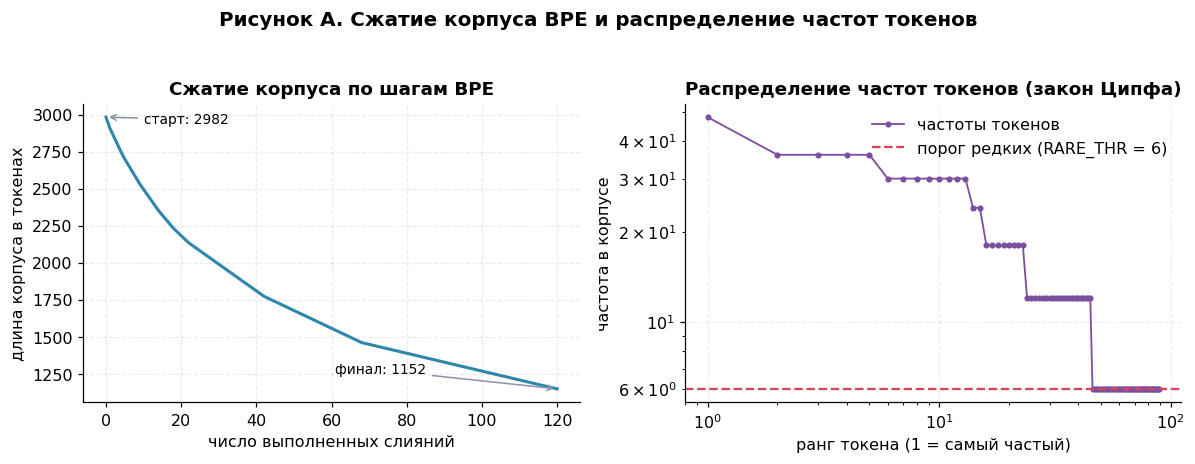

токенов в словаре: 89
редких токенов (частота <= 6): 44 (49.4%)


In [ ]:
# TODO A.3: рисунок A: длина корпуса от числа слияний + частоты токенов (закон Ципфа)
# слева: lengths от номера слияния
# справа: отсортированные по убыванию частоты токенов в log-log осях,
#         отметьте горизонтальной линией порог «редкий токен» (частота <= RARE_THR)
RARE_THR = 6

# --- собираем частоты отдельных токенов из итогового словаря ---
# vocab: {кортеж_символов_слова: частота_слова}
# token_freq: {отдельный_токен: суммарная_частота_по_корпусу}
token_freq = {}
for seq, freq in vocab.items():
    for tok in seq:
        token_freq[tok] = token_freq.get(tok, 0) + freq

# сортируем по убыванию частоты — так получим «кривую Ципфа»
freqs_sorted = np.array(sorted(token_freq.values(), reverse=True))
ranks = np.arange(1, len(freqs_sorted) + 1)   # ранг токена: 1 у самого частого

# доля редких токенов (частота <= RARE_THR)
n_rare = int((freqs_sorted <= RARE_THR).sum())
rare_share = n_rare / len(freqs_sorted)

# --- рисуем ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# левая панель: длина корпуса от числа слияний
ax = axes[0]
ax.plot(range(len(lengths)), lengths, color=PALETTE["attn"], lw=2)
ax.set_xlabel("число выполненных слияний")
ax.set_ylabel("длина корпуса в токенах")
ax.set_title("Сжатие корпуса по шагам BPE")
ax.annotate(f"старт: {lengths[0]}",
            xy=(0, lengths[0]), xytext=(10, lengths[0] - 40),
            arrowprops=dict(arrowstyle="->", color=PALETTE["gray"]), fontsize=9)
ax.annotate(f"финал: {lengths[-1]}",
            xy=(len(lengths) - 1, lengths[-1]),
            xytext=(len(lengths) - 60, lengths[-1] + 100),
            arrowprops=dict(arrowstyle="->", color=PALETTE["gray"]), fontsize=9)
# отметка порога редких токенов не нужна здесь — она на правой панели

# правая панель: закон Ципфа в log-log
ax = axes[1]
ax.loglog(ranks, freqs_sorted, marker="o", ms=3, lw=1.2,
          color=PALETTE["accent"], label="частоты токенов")
ax.axhline(RARE_THR, color=PALETTE["bad"], ls="--", lw=1.5,
           label=f"порог редких (RARE_THR = {RARE_THR})")
ax.set_xlabel("ранг токена (1 = самый частый)")
ax.set_ylabel("частота в корпусе")
ax.set_title("Распределение частот токенов (закон Ципфа)")
ax.legend(loc="upper right")

finish(fig, "Рисунок A. Сжатие корпуса BPE и распределение частот токенов")
print(f"токенов в словаре: {len(token_freq)}")
print(f"редких токенов (частота <= {RARE_THR}): {n_rare} ({rare_share:.1%})")

**Левый график — сжатие корпуса по шагам BPE.** Кривая начинается в точке 2982 токена (это исходная посимвольная разбивка корпуса) и за 120 слияний опускается до 1152. Главное, что здесь видно: скорость сжатия резко падает. Первые ~20 слияний убирают почти 700 токенов — это самые частые пары, которые встречаются во множестве слов. Следующие 100 слияний добавляют всего около 400 токенов экономии. Это типичная картина для BPE: выгода от каждого следующего слияния убывает, потому что частые пары заканчиваются, а остаются редкие комбинации, которые дают мало. Практический вывод — увеличивать число слияний до бесконечности бессмысленно: где-то после 100–200 шагов отдача падает почти до нуля, а словарь растёт.

**Правый график — распределение частот токенов.** Ступенчатая форма — это не ошибка, а следствие маленького корпуса: частоты принимают дискретные значения (6, 12, 18, 24, 30, 48), потому что каждое слово повторяется в корпусе ровно 6 раз, а токены встречаются целым числом слов. Самый частый токен имеет частоту 48, то есть встречается почти в каждом предложении корпуса. Дальше частота монотонно падает до 6. В реальных корпусах хвост был бы гораздо длиннее, но даже здесь форма закона Ципфа узнаваема — несколько «тяжёлых» токенов и длинный хвост.

**Вопрос A.** Во сколько раз выросла бы стоимость слоя внимания, если перейти от BPE к посимвольной
токенизации при том же тексте? Используйте измеренный коэффициент сжатия и зависимость $O(n^2)$.

**Ответ A.**

## Ответ на вопрос A

Стоимость слоя внимания растёт как `O(n²)`, где `n` — длина последовательности в токенах. Значит, при переходе от BPE к посимвольной токенизации длина вырастет ровно во столько раз, во сколько BPE сжал текст — то есть в **2.30 раза** (коэффициент сжатия «символы → BPE»). Стоимость внимания при этом вырастет в квадрат этого числа:

```
2.30² ≈ 5.29
```

## Часть B. Затухание градиента в рекуррентной сети

Для рекуррентности $h_t = \phi(W h_{t-1} + U x_t)$ производная по состоянию, удалённому на $k$ шагов,
содержит произведение $k$ матриц:

$
\frac{\partial h_T}{\partial h_{T-k}} = \prod_{j=0}^{k-1} \operatorname{diag}(\phi')\, W .
$

Норма такого произведения ведёт себя как $\rho(W)^k$. Аддитивный путь с гейтом $f_t$ даёт вместо
этого множитель $\prod f_t$, который при $f_t \to 1$ почти не затухает.

**Задание B.1.** Вычислите норму произведения $k$ матриц с заданным спектральным радиусом.
**Задание B.2.** Постройте график нормы от $k$ для $\rho \in \{0.9, 1.0, 1.2\}$ и добавьте
аддитивные пути с $f_t = 0.99$ и $f_t = 0.95$.
**Задание B.3.** Найдите эффективный горизонт памяти: при каком $k$ норма падает ниже $10^{-6}$.

Рекуррентная нейронная сеть (RNN) обрабатывает последовательность по одному элементу за раз, поддерживая **скрытое состояние** — вектор, который «помнит» всё, что сеть видела до момента $t$. Обновление состояния на каждом шаге:

$$
h_t = \phi(W h_{t-1} + U x_t)
$$

Обозначения:

- $h_t \in \mathbb{R}^d$ — скрытое состояние в момент $t$;
- $\mathbb{R}^d$ - вектор из $d$ вещественных чисел
- $x_t$ — входной вектор в момент $t$;
- $W \in \mathbb{R}^{d \times d}$ — **рекуррентная матрица**, задающая, как старое состояние переходит в новое;
- $U$ — матрица, проецирующая вход в пространство состояний;
- $\phi$ — нелинейность (обычно $\tanh$ или сигмоида), применяется покоординатно.

$W$ **одна и та же** на каждом шаге. Именно это делает сеть рекуррентной — переиспользуется одна и та же операция, а не учится отдельная матрица на каждую позицию.

Обучение идёт через **backpropagation through time** — обратное распространение сквозь время. Когда мы корректируем параметры по ошибке на позиции $T$, градиент должен «дойти» до всех предыдущих позиций, потому что они повлияли на $h_T$ через цепочку обновлений:

$$
h_{T-k} \;\to\; h_{T-k+1} \;\to\; \dots \;\to\; h_{T-1} \;\to\; h_T
$$

Чтобы понять, как ошибка на шаге $T$ влияет на состояние на шаге $T-k$, считаем производную $\dfrac{\partial h_T}{\partial h_{T-k}}$. Она показывает, насколько изменится финальное состояние, если чуть-чуть сдвинуть состояние $k$ шагов назад. Именно эта величина определяет, **дойдёт ли сигнал обучения до далёкого прошлого**.

Разложим производную по цепному правилу. Связь между соседними состояниями:

$$
h_t = \phi(W h_{t-1} + U x_t)
$$

Производная $h_t$ по $h_{t-1}$:

$$
\frac{\partial h_t}{\partial h_{t-1}} = \operatorname{diag}\bigl(\phi'(W h_{t-1} + U x_t)\bigr) \cdot W
$$

Теперь пройдём $k$ шагов и перемножим производные для каждого перехода:

$$
\frac{\partial h_T}{\partial h_{T-k}} = \prod_{j=0}^{k-1} \operatorname{diag}\bigl(\phi'\bigr) \, W
$$

Производная по состоянию, удалённому на $k$ шагов, — это произведение $k$ матриц, каждая из которых есть «диагональ производных нелинейности, умноженная на $W$».

Норма произведения $k$ матриц примерно ведёт себя как $k$-я степень некоторого характерного масштаба. Если пренебречь диагональным множителем (в среднем он порядка единицы), то

$$
\left\| \frac{\partial h_T}{\partial h_{T-k}} \right\| \;\sim\; \rho(W)^k
$$

где $\rho(W)$ — **спектральный радиус** матрицы $W$, то есть максимальный модуль её собственного значения:

$$
\rho(W) = \max_i |\lambda_i(W)|
$$

Спектральный радиус показывает, во сколько раз в среднем за один шаг растягивается или сжимается вектор при умножении на $W$.

Отсюда три режима:

- $\rho(W) < 1$ — норма падает экспоненциально с ростом $k$. Это **затухание градиента**: сигнал от далёкого прошлого практически не доходит, сеть не может выучить длинные зависимости.
- $\rho(W) > 1$ — норма растёт экспоненциально. Это **взрыв градиента**: обучение становится нестабильным, веса «улетают». Обычно лечится клиппингом (обрезанием нормы градиента).
- $\rho(W) = 1$ — норма держится примерно на одном уровне. Теоретически идеальный режим для памяти, но на практике нелинейность $\phi'$ всё равно тянет норму вниз.

Классическая RNN обновляет состояние целиком, поэтому память «перезаписывается» на каждом шаге. Как решается: вводится **аддитивный путь** — отдельная «линия памяти», к которой новое содержимое не заменяет старое, а добавляется через гейт.

**Гейт** — это вектор значений в интервале $(0, 1)$, который покоординатно умножается на другой вектор. Он работает как плавный переключатель:

- значение близко к $1$ — «пропустить сигнал»;
- значение близко к $0$ — «заблокировать сигнал».

Формально гейт — это выход сигмоиды:

$$
f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f)
$$

где $\sigma(z) = \dfrac{1}{1 + e^{-z}}$ — сигмоида, сжимающая любое число в $(0, 1)$. Гейт **зависит от входа и от предыдущего состояния**, то есть сеть сама решает, что забыть, а что оставить. Это обучаемое поведение, а не фиксированное правило.

$$
h_t = f_t \odot h_{t-1} + (1 - f_t) \odot \tilde{h}_t
$$

- $h_{t-1}$ — старое состояние (память);
- $\tilde{h}_t$ — **кандидат** на новое содержимое. Обычно считается как $\tilde{h}_t = \tanh(W_h x_t + U_h h_{t-1} + b_h)$ — это то, что сеть «хотела бы» записать в память;
- $f_t \in (0, 1)^d$ — **гейт забывания**, покоординатный;
- $(1 - f_t) \in (0, 1)^d$ — **гейт записи**: то, что мы не оставили, мы заменяем новым;

Теперь посмотрим на производную по прошлому состоянию:

$$
\frac{\partial h_t}{\partial h_{t-1}} = \operatorname{diag}(f_t) + \text{(слагаемые от } \tilde{h}_t \text{ и гейтов)}
$$

Главное — первое слагаемое $\operatorname{diag}(f_t)$. Оно **не содержит умножения на $W$** и потому не масштабируется спектральным радиусом. Пройдя $k$ шагов, получаем множитель:

$$
\prod_{j=0}^{k-1} f_{t-j}
$$

Если гейт держится близко к единице ($f_t \approx 1$), то произведение почти не убывает — сигнал «протекает» через сотни шагов без экспоненциального затухания. Это и есть **аддитивный путь**: память сохраняется, потому что старое состояние не домножается на матрицу, а просто умножается на скаляр, близкий к единице.

In [ ]:
# Часть B.1 и B.3: затухание градиента в рекуррентной сети
# ----------------------------------------------------------
# Идея: строим матрицу W с заданным спектральным радиусом rho и считаем
# нормы последовательных степеней ||W^k||_2. Теоретически они ведут себя
# как rho^k, что и проверяем численно. Горизонт памяти — минимальное k,
# при котором норма падает ниже порога.


def make_W(d, rho, gen):
    """Случайная матрица d x d с заданным спектральным радиусом rho.

    Спектральный радиус — это max |собственное значение|. Он показывает,
    во сколько раз в среднем за один шаг матрица растягивает или сжимает
    вектор. Алгоритм:
      1) берём случайную гауссову матрицу и нормируем на sqrt(d);
      2) считаем её текущий спектральный радиус;
      3) масштабируем так, чтобы он стал ровно rho.
    """
    A = gen.normal(size=(d, d)) / np.sqrt(d)              # случайная матрица, устойчивая по d
    eig_max = np.max(np.abs(np.linalg.eigvals(A)))        # текущий спектральный радиус
    return A * rho / eig_max                              # масштабируем до целевого rho


def grad_norms(rho, k_max=120, d=32, seed=0):
    """Нормы ||W^k||_2 для k = 1..k_max.

    Параметры:
        rho   — целевой спектральный радиус матрицы W;
        k_max — максимальная длина произведения;
        d     — размерность матрицы W;
        seed  — seed для генератора случайных чисел.

    Возвращает:
        np.ndarray длины k_max, где индекс k-1 хранит ||W^k||_2.
    """
    gen = np.random.default_rng(seed)
    W = make_W(d, rho, gen)              # матрица с заданным спектральным радиусом

    norms = np.empty(k_max)              # сюда пишем нормы по шагам
    P = W.copy()                         # P = W^1 на первом шаге
    norms[0] = np.linalg.norm(P, 2)      # спектральная норма ||W||

    for k in range(1, k_max):
        P = P @ W                        # накопление степени: W^k = W^(k-1) @ W
        norms[k] = np.linalg.norm(P, 2)

    return norms


def horizon(rho, thr=1e-6, k_max=4000, d=32, seed=0):
    """Наименьшее k, при котором ||W^k||_2 падает ниже thr.

    Оцениваем норму теоретически как rho**k, чтобы не перемножать
    тысячи матриц. Из уравнения rho^k = thr получаем
        k = log(thr) / log(rho).
    Если rho >= 1, норма не убывает, горизонт недостижим -> np.inf.
    """
    if rho >= 1.0:
        return np.inf                    # затухания нет, горизонт бесконечен
    k = int(np.ceil(np.log(thr) / np.log(rho)))   # наименьшее целое k с rho^k <= thr
    return min(k, k_max)


# --- быстрая проверка ---
print("проверка горизонта:")
for rho in [0.9, 0.99, 1.0, 1.2]:
    print(f"  rho = {rho}: horizon = {horizon(rho)}")

проверка горизонта:
  rho = 0.9: horizon = 132
  rho = 0.99: horizon = 1375
  rho = 1.0: horizon = inf
  rho = 1.2: horizon = inf


**`rho = 0.9: horizon = 132`** — сигнал затухает настолько, что через 132 шага норма произведения падает ниже $10^{-6}$. То есть сеть с такой матрицей **практически не помнит** ничего, что было дальше ~130 шагов назад. Градиент от ошибки просто не доходит до далёкого прошлого.

**`rho = 0.99: horizon = 1375`** — почти то же основание, но горизонт в 10 раз длиннее. Это иллюстрирует, насколько **резко** память зависит от $\rho$ вблизи единицы: изменение $\rho$ на 0.09 даёт рост горизонта в 10 раз.

**`rho = 1.0: horizon = inf`** — норма не убывает: $1^k = 1$ при любом $k$. Сигнал держится на одном уровне сколько угодно долго. Теоретически идеальный режим для памяти, но на практике недостижим: нелинейность $\phi'$ в произведении всё равно тянет норму вниз, а численные ошибки копятся.

**`rho = 1.2: horizon = inf`** — здесь горизонт формально «бесконечен», но по другой причине: норма не **падает**, а **растёт**. Сигнал не затухает, а взрывается. Обучение с такой матрицей нестабильно, нужен клиппинг градиента.

**Главный вывод:** между «забыть всё» ($\rho = 0.9$) и «взорваться» ($\rho = 1.2$) есть узкая зона около $\rho = 1$, где память живёт долго. Именно поэтому в чистой RNN так тяжело настроить обучение на длинные зависимости — нужно попасть почти точно в $\rho = 1$, а нелинейности и шум этому мешают.

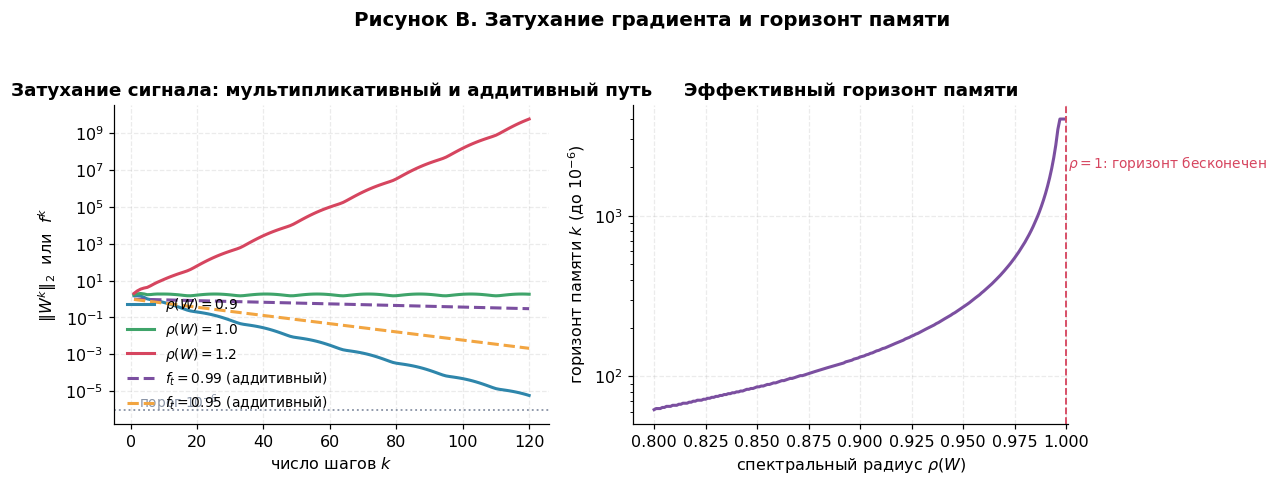

In [ ]:
# TODO B.2: рисунок B: слева нормы от k в логарифмической шкале для трёх значений rho
#           и две линии аддитивного пути f**k (f = 0.99 и 0.95);
#           справа эффективный горизонт памяти horizon(rho) для rho от 0.8 до 0.999

# --- данные для левой панели ---
K_MAX = 120
ks = np.arange(1, K_MAX + 1)                 # номера шагов k = 1..K_MAX

# нормы для трёх значений спектрального радиуса
norms_09 = grad_norms(0.9, k_max=K_MAX)      # затухающий режим
norms_10 = grad_norms(1.0, k_max=K_MAX)      # критический режим
norms_12 = grad_norms(1.2, k_max=K_MAX)      # взрывной режим

# аддитивные пути: f**k при f = 0.99 и f = 0.95
f_99 = 0.99 ** ks                            # гейт почти не забывает
f_95 = 0.95 ** ks                            # гейт забывает заметно быстрее

# --- данные для правой панели ---
rhos = np.linspace(0.8, 0.999, 200)          # сетка по rho
horizons = np.array([horizon(r) for r in rhos])

# --- рисунок ---
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

# левая панель: нормы от k в log-шкале
ax = axes[0]
ax.semilogy(ks, norms_09, color=PALETTE["attn"], lw=2, label=r"$\rho(W)=0.9$")
ax.semilogy(ks, norms_10, color=PALETTE["good"], lw=2, label=r"$\rho(W)=1.0$")
ax.semilogy(ks, norms_12, color=PALETTE["bad"], lw=2, label=r"$\rho(W)=1.2$")
ax.semilogy(ks, f_99, color=PALETTE["accent"], lw=2, ls="--", label=r"$f_t=0.99$ (аддитивный)")
ax.semilogy(ks, f_95, color=PALETTE["linear"], lw=2, ls="--", label=r"$f_t=0.95$ (аддитивный)")
ax.axhline(1e-6, color=PALETTE["gray"], ls=":", lw=1.2)
ax.text(K_MAX * 0.02, 1.2e-6, r"порог $10^{-6}$", color=PALETTE["gray"], fontsize=9)
ax.set_xlabel("число шагов $k$")
ax.set_ylabel(r"$\|W^k\|_2$  или  $f^k$")
ax.set_title("Затухание сигнала: мультипликативный и аддитивный путь")
ax.legend(loc="lower left", fontsize=9)

# правая панель: горизонт памяти как функция rho
ax = axes[1]
# убираем inf-точки, чтобы semilogy не ругался: рисуем только конечные значения
finite = np.isfinite(horizons)
ax.semilogy(rhos[finite], horizons[finite], color=PALETTE["accent"], lw=2)
ax.axvline(1.0, color=PALETTE["bad"], ls="--", lw=1.2)
ax.text(1.001, horizons[finite].max() * 0.5, r"$\rho=1$: горизонт бесконечен",
        color=PALETTE["bad"], fontsize=9)
ax.set_xlabel(r"спектральный радиус $\rho(W)$")
ax.set_ylabel(r"горизонт памяти $k$ (до $10^{-6}$)")
ax.set_title("Эффективный горизонт памяти")
ax.set_xlim(0.79, 1.001)

finish(fig, "Рисунок B. Затухание градиента и горизонт памяти")

**Левая панель — затухание сигнала.** По горизонтали отложено число шагов $k$ (сколько раз мы умножили матрицу на себя), по вертикали — норма $\|W^k\|_2$ или $f^k$ в логарифмической шкале.

Мультипликативный путь (сплошные линии, это степени $\rho^k$):

- **красная** ($\rho = 1.2$) уходит **вверх** по экспоненте: от $10^0$ в начале до $10^9$ к $k = 120$. Это режим взрыва градиента — обучение нестабильно.
- **зелёная** ($\rho = 1.0$) держится горизонтально на уровне 1: $1^k = 1$ при любом $k$. Идеальная память, но на практике недостижима.
- **синяя** ($\rho = 0.9$) падает вниз: к $k = 120$ опускается до $\approx 10^{-5}$. Именно эта линия первой пересекает порог $10^{-6}$ — тот самый горизонт 132 шага из прошлой ячейки.

Аддитивный путь (пунктирные линии, это степени $f^k$):

- **фиолетовая** ($f = 0.99$) идёт почти горизонтально: к $k = 120$ держится около $0.3$. То есть сигнал ослаб всего в 3 раза за 120 шагов — это уровень, который $\rho = 0.9$ теряет уже к 10-му шагу.
- **оранжевая** ($f = 0.95$) падает быстрее, но всё равно к $k = 120$ остаётся около $10^{-3}$ — на два порядка выше, чем $\rho = 0.9$.

Куда смотреть в первую очередь: **сравнить синюю сплошную и фиолетовую пунктирную**. Обе примерно одного «порядка основания» (0.9 vs 0.99), но к концу графика между ними разрыв в **четыре порядка**. Это и есть визуальное доказательство главного тезиса части B: аддитивный путь с гейтом сохраняет память радикально лучше мультипликативного с матрицей, потому что в нём нет умножения на $W$ на каждом шаге.

**Правая панель — горизонт памяти как функция $\rho$.** По горизонтали — спектральный радиус от 0.8 до 0.999, по вертикали — $k$, при котором норма падает до $10^{-6}$ (в логарифмической шкале). Кривая растёт гиперболически. Главное, что показывает график: горизонт крайне чувствителен к $\rho$ вблизи единицы.

**Вопрос B.** Пусть требуется удерживать зависимость длиной 500 шагов с ослаблением сигнала не
более чем в 10 раз. Какое значение гейта $f_t$ для этого нужно? Сравните с $\rho(W)$, необходимым в
чистой рекуррентности.

**Ответ B.**

### Случай 1: аддитивный путь (гейт $f_t$)

Ослабление сигнала за 500 шагов — это $f^{500}$. Требование «не более чем в 10 раз» записывается как:

$$
f^{500} \ge \frac{1}{10} = 0.1
$$

Логарифмируем:

$$
500 \ln f \ge \ln 0.1 \;\Longrightarrow\; \ln f \ge \frac{-2.3026}{500} \approx -0.004605
$$

$$
f \ge e^{-0.004605} \approx 0.9954
$$

**Ответ: $f_t \approx 0.995$.**

### Случай 2: чистая рекуррентность (спектральный радиус $\rho(W)$)

То же требование, но затухание идёт как $\rho^{500}$:

$$
\rho^{500} \ge 0.1 \;\Longrightarrow\; \ln \rho \ge \frac{\ln 0.1}{500} \approx -0.004605
$$

$$
\rho \ge e^{-0.004605} \approx 0.9954
$$

**Ответ: $\rho(W) \approx 0.995$.**

Формально нужное значение $0.995$ одинаково для обоих случаев, но в аддитивном пути это стабильная, локально обучаемая величина, которую легко поддерживать; в мультипликативном — глобальная и хрупкая характеристика, которую очень трудно удержать в узкой зоне. Именно поэтому гейты выигрывают не по математике, а по **устойчивости обучения**.

## Часть C. Внимание с нуля и роль масштабирования

$
\operatorname{Attention}(Q,K,V) = \operatorname{softmax}\!\left(\frac{QK^{\top}}{\sqrt{d_k}}\right) V .
$

Делитель $\sqrt{d_k}$ не косметика: при $q,k \sim \mathcal N(0,1)$ скалярное произведение имеет
дисперсию $d_k$, и без нормировки softmax при больших $d_k$ вырождается почти в one-hot, что
обнуляет градиент по ключам.

**Задание C.1.** Реализуйте одну голову внимания с каузальной маской и без неё.
**Задание C.2.** Проверьте два обязательных свойства: строки матрицы внимания суммируются в единицу,
а при каузальной маске верхний треугольник строго нулевой.
**Задание C.3.** Измерьте среднюю энтропию распределения внимания как функцию $d_k$ с делителем и
без него, постройте рисунок с картами внимания и графиком энтропии.

В рекуррентной сети каждый токен влияет на следующий через скрытое состояние — информация идёт «по цепочке», и дальний токен добирается до текущего через много шагов. Внимание ломает эту схему: **каждая позиция может напрямую обратиться к любой другой**, минуя цепочку.

У каждого токена есть три вектора — **запрос (query)**, **ключ (key)** и **значение (value)**. Они получаются линейным преобразованием из эмбеддинга токена:

$$
Q = X W_Q, \qquad K = X W_K, \qquad V = X W_V
$$

где $X \in \mathbb{R}^{n \times d}$ — матрица эмбеддингов всех $n$ токенов, а $W_Q, W_K, W_V$ — обучаемые матрицы $d \times d_k$.

Эмбеддинг — это векторное представление дискретного объекта (токена).

 Смысл аналогии:

- **Query** — запрос текущего токена;
- **Key** — метка токена, по которой его можно найти;
- **Value** — содержимое, которое передаётся, если токен выбран.

$$
\operatorname{Attention}(Q, K, V) = \operatorname{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V
$$

Все матрицы $Q, K, V$ имеют размер $n \times d_k$ (где $n$ — длина последовательности, $d_k$ — размерность одного вектора).

**Шаг 1. Сходство запросов с ключами: $S = Q K^\top$.**

$Q$ — это $n \times d_k$, $K^\top$ — это $d_k \times n$. Их произведение — матрица $n \times n$. Элемент $S_{ij}$ — это скалярное произведение запроса $i$-го токена на ключ $j$-го токена. Чем больше $S_{ij}$, тем «более похожи» запрос $i$ и ключ $j$, то есть тем сильнее токен $i$ хочет обратиться к токену $j$. Это матрица «оценок релевантности».

**Шаг 2. Масштабирование: $S / \sqrt{d_k}$.**

Делим все оценки на $\sqrt{d_k}$, чтобы не было обнуления градиента

**Шаг 3. Softmax по строкам: $A = \operatorname{softmax}(S / \sqrt{d_k})$.**

Softmax берётся **по каждой строке отдельно**. После этого каждая строка $A_i$ — это распределение вероятностей: $A_{ij} \ge 0$ и $\sum_j A_{ij} = 1$. Смысл: токен $i$ распределяет своё «внимание» между всеми токенами $j$, и $A_{ij}$ — это доля внимания, которую он отдаёт токену $j$. Если $A_{ij} \approx 1$, токен $i$ почти целиком смотрит на токен $j$; если все $A_{ij} = 1/n$, он смотрит на всех поровну.

**Шаг 4. Взвешенная сумма значений: $O = A V$.**

$A$ — это $n \times n$, $V$ — это $n \times d_k$, произведение — $n \times d_k$. Каждая строка результата $O_i$ — это взвешенная сумма всех значений $V_j$ с весами $A_{ij}$:

$$
O_i = \sum_{j=1}^{n} A_{ij} V_j
$$

То есть выход для токена $i$ — это «смесь» всех значений, где вес каждого значения определяется тем, насколько релевантен соответствующий ключ запросу $i$.

В задачах генерации токен $i$ не должен видеть будущие токены $j > i$. Чтобы это обеспечить, перед softmax к логитам прибавляют $-\infty$ для всех позиций $j > i$:

$$
S_{ij} \leftarrow \begin{cases} S_{ij}, & j \le i \\ -\infty, & j > i \end{cases}
$$

После softmax эти позиции получают вес $e^{-\infty} = 0$, и токен $i$ может смотреть только на прошлое и на себя. Это **каузальная маска** — верхний треугольник матрицы внимания обнуляется.

In [ ]:
# Часть C.1 и C.3a: scaled dot-product attention и энтропия внимания
# ---------------------------------------------------------------
# Q, K, V — обычные массивы.
# Делитель sqrt(d_k) возвращает дисперсию логитов к 1, иначе softmax
# вырождается в one-hot и градиенты обнуляются.


def attention(Q, K, V, causal=True, scale=True):
    """Масштабированное скалярное внимание.

    Параметры:
        Q : (n, d_k) — запросы
        K : (n, d_k) — ключи
        V : (n, d_v) — значения
        causal : bool — если True, запрещаем смотреть в будущее
        scale  : bool — если True, делим логиты на sqrt(d_k)

    Возвращает:
        out : (n, d_v) — выход внимания
        A   : (n, n)   — матрица внимания (строки суммируются в 1)
    """
    n, d_k = Q.shape

    # 1) оценки релевантности: скалярное произведение каждого запроса
    #    на каждый ключ. S[i, j] — «насколько токен i хочет смотреть на j»
    S = Q @ K.T                                     # (n, n)

    # 2) масштабирование: без него при больших d_k дисперсия логитов
    #    растёт как d_k, и softmax становится почти one-hot
    if scale:
        S = S / np.sqrt(d_k)

    # 3) каузальная маска: в верхнем треугольнике (без диагонали) ставим -inf,
    #    чтобы после softmax эти позиции получили вес ровно 0
    if causal:
        mask = np.triu(np.ones((n, n), dtype=bool), k=1)   # True выше главной диагонали
        S = np.where(mask, -np.inf, S)

    # 4) устойчивый softmax по строкам: вычитаем максимум каждой строки,
    #    чтобы избежать переполнения exp. Результат не меняется,
    #    т.к. числитель и знаменатель делятся на одну и ту же константу.
    S_max = np.max(S, axis=1, keepdims=True)
    # для строк, целиком состоящих из -inf (теоретически возможно),
    # подставляем 0, чтобы не получить nan - 0
    S_max = np.where(np.isfinite(S_max), S_max, 0.0)
    E = np.exp(S - S_max)
    A = E / np.sum(E, axis=1, keepdims=True)       # (n, n), строки суммируются в 1

    # 5) взвешенная сумма значений: каждая строка out[i] — смесь значений
    #    с весами из строки A[i]
    out = A @ V                                     # (n, d_v)
    return out, A


def mean_entropy(d_k, scale, n=64, trials=40, seed=0):
    """Средняя энтропия строк матрицы внимания для случайных Q, K ~ N(0, 1).

    Энтропия строки p: H(p) = -sum_j p_j * log(p_j).
    Максимум — ln(n) (равномерное распределение), минимум — 0 (one-hot).
    Чем ближе энтропия к нулю, тем сильнее вырожден softmax.

    Параметры:
        d_k    — размерность векторов ключей/запросов
        scale  — если True, делим логиты на sqrt(d_k)
        n      — длина последовательности (число токенов)
        trials — сколько случайных пар (Q, K) усредняем
        seed   — seed генератора

    Возвращает:
        средняя энтропия по всем строкам и всем trials.
    """
    gen = np.random.default_rng(seed)
    entropies = []

    for _ in range(trials):
        Q = gen.normal(size=(n, d_k))                # случайные запросы
        K = gen.normal(size=(n, d_k))                # случайные ключи
        _, A = attention(Q, K, np.eye(n), causal=False, scale=scale)
        # энтропия каждой строки: -sum p * log p
        # добавляем 1e-12, чтобы log(0) не давал -inf (хотя нулей быть не должно)
        H_rows = -(A * np.log(A + 1e-12)).sum(axis=1)   # (n,)
        entropies.append(H_rows.mean())

    return float(np.mean(entropies))


# --- быстрая проверка ---
print("энтропия при d_k = 16:")
print(f"  с делителем:  {mean_entropy(16, scale=True):.3f}  (макс ln(64) = {np.log(64):.3f})")
print(f"  без делителя: {mean_entropy(16, scale=False):.3f}")

энтропия при d_k = 16:
  с делителем:  3.692  (макс ln(64) = 4.159)
  без делителя: 1.389


Для дискретного распределения $p = (p_1, p_2, \dots, p_n)$, где $p_i \ge 0$ и $\sum_i p_i = 1$, энтропия по Шеннону:

$$
H(p) = -\sum_{i=1}^{n} p_i \log p_i
$$

Логарифм обычно натуральный — тогда энтропия измеряется в **натах**. Если взять $\log_2$, получим биты; разница только в множителе.

Энтропия — это **мера неопределённости** распределения. Она отвечает на вопрос: «насколько трудно угадать, какое значение выпадет?»

- **Минимум $H = 0$** достигается на вырожденном распределении, где вся вероятность сосредоточена в одной точке: $p = (1, 0, 0, \dots, 0)$. Угадать результат можно наверняка — неопределённости нет.
- **Максимум $H = \ln n$** достигается на равномерном распределении $p = (1/n, 1/n, \dots, 1/n)$. Все исходы равновероятны — угадать сложно. Чем больше $n$, тем выше потолок.

Все остальные распределения лежат где-то между этими крайностями: чем «размазаннее» вероятностная масса, тем ближе энтропия к $\ln n$; чем более сконцентрирована — тем ближе к нулю.

В части C энтропия применяется к **каждой строке матрицы внимания** $A_i$. Строка $A_i$ — это распределение вероятностей: сколько токен $i$ отдаёт внимания каждому токену $j$.

- Если строка близка к one-hot (один вес $\approx 1$, остальные $\approx 0$) — энтропия близка к нулю. Токен смотрит только на одну позицию, распределение вырождено.
- Если строка близка к равномерной ($A_{ij} = 1/n$ для всех $j$) — энтропия близка к $\ln n$. Токен смотрит на всех одинаково.
- Промежуточные значения — токен распределяет внимание между несколькими важными позициями.

Именно поэтому энтропия — идеальная метрика для демонстрации эффекта делителя $\sqrt{d_k}$: она напрямую измеряет, насколько «резким» получилось распределение внимания.

In [ ]:
# TODO C.2: проверка свойств внимания (с наглядным выводом матриц)
g = np.random.default_rng(SEED)
Qt = g.normal(size=(8, 16))
Kt = g.normal(size=(8, 16))
Vt = g.normal(size=(8, 3))

# --- дополнительно считаем логиты вручную, чтобы показать их до softmax ---
S_raw = Qt @ Kt.T / np.sqrt(16)              # логиты без маски
mask = np.triu(np.ones((8, 8), dtype=bool), k=1)
S_masked = np.where(mask, -np.inf, S_raw)    # логиты с маской (в верхнем треугольнике -inf)

# --- основная функция ---
_, Wt = attention(Qt, Kt, Vt, causal=True, scale=True)

# --- C.2a: суммы по строкам равны 1 ---
row_sums = Wt.sum(axis=1)
assert np.allclose(row_sums, np.ones_like(row_sums), atol=1e-10), \
    "строки матрицы внимания не суммируются в 1"

# --- C.2b: верхний треугольник (без диагонали) строго нулевой ---
upper = Wt[np.triu_indices(8, k=1)]
assert np.allclose(upper, 0.0, atol=1e-12), \
    "при каузальной маске верхний треугольник должен быть нулевым"

# --- C.2c: максимальное отклонение сумм строк от единицы ---
max_dev = float(np.abs(row_sums - 1.0).max())
print(f"максимальное отклонение сумм строк от 1: {max_dev:.2e}")
print(f"максимальное значение в верхнем треугольнике: {float(np.abs(upper).max()):.2e}")
print("обе проверки пройдены\n")

# --- наглядный вывод: логиты после маски ---
# -inf при печати мешает, поэтому показываем их как «--»
def show_matrix(M, fmt="{:8.3f}", inf_marker="     -- "):
    """Печатает матрицу, заменяя -inf на читаемый маркер."""
    for row in M:
        cells = []
        for x in row:
            cells.append(inf_marker if not np.isfinite(x) else fmt.format(x))
        print(" ".join(cells))

print("Логиты QK^T / sqrt(d_k) с каузальной маской (-- = -inf):")
show_matrix(S_masked)
print()

print("Матрица внимания после softmax (строки суммируются в 1):")
show_matrix(Wt)
print()

print("Суммы строк:", np.round(row_sums, 4))
print("Максимум в строке 0:", Wt[0].max(), "| argmax:", Wt[0].argmax())

максимальное отклонение сумм строк от 1: 2.22e-16
максимальное значение в верхнем треугольнике: 0.00e+00
обе проверки пройдены

Логиты QK^T / sqrt(d_k) с каузальной маской (-- = -inf):
   0.105      --       --       --       --       --       --       -- 
  -0.545    0.852      --       --       --       --       --       -- 
   0.144   -0.300    0.450      --       --       --       --       -- 
  -0.884    0.149   -0.062    0.994      --       --       --       -- 
  -0.258    0.398    0.833   -0.068    1.136      --       --       -- 
   0.451    0.792   -0.254    0.431   -0.162   -0.414      --       -- 
   0.852    0.141   -0.299    0.262    0.382    0.200    0.227      -- 
  -1.847    0.484   -2.445   -0.668    0.230   -1.380   -0.720    1.858

Матрица внимания после softmax (строки суммируются в 1):
   1.000    0.000    0.000    0.000    0.000    0.000    0.000    0.000
   0.198    0.802    0.000    0.000    0.000    0.000    0.000    0.000
   0.333    0.214    0.453    0.000  

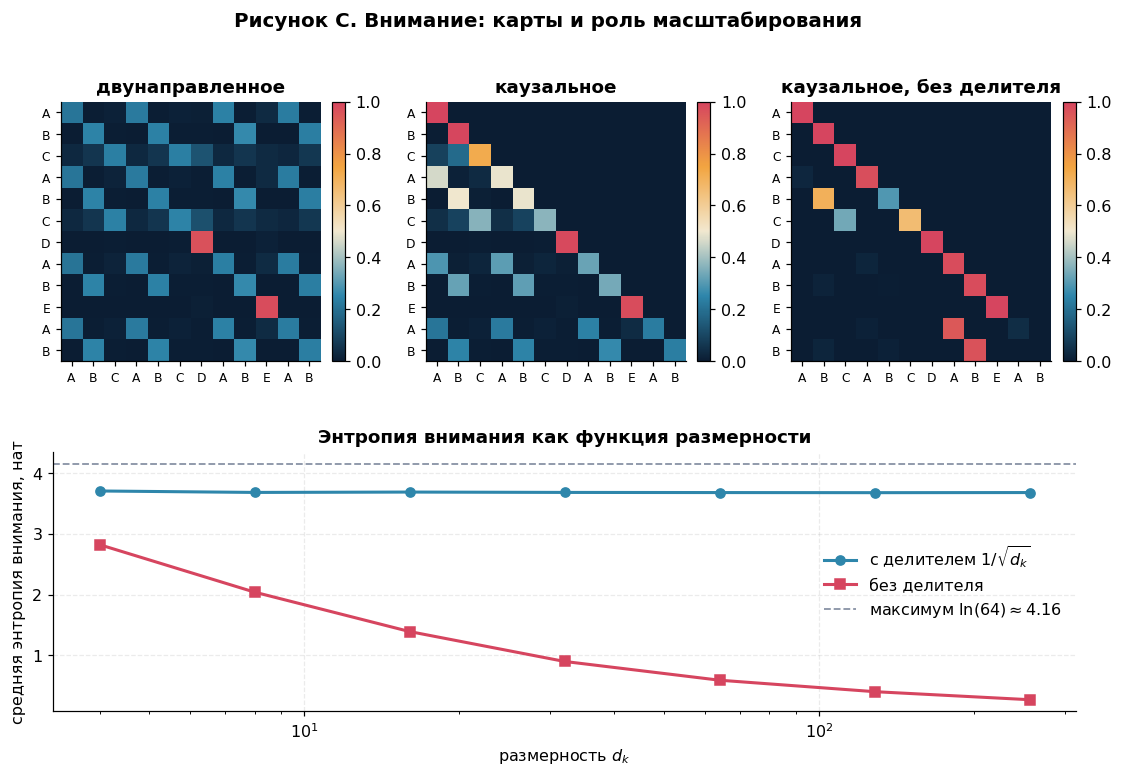

In [ ]:
# TODO C.3b: рисунок C:
#   верхний ряд — три карты внимания: двунаправленная, каузальная, без делителя (Q*4, K*4)
#   нижний ряд — энтропия внимания от d_k с делителем и без, с линией ln(64)
# используйте последовательность labels ниже: повторяющийся паттерн даёт наглядные карты
n_tok, d_k = 12, 16
labels = ["A", "B", "C", "A", "B", "C", "D", "A", "B", "E", "A", "B"]

# --- конструируем Q и K так, чтобы они отражали метки ---
# каждой букве сопоставим свой случайный центр в R^d_k; вектор токена = центр + шум.
g = np.random.default_rng(SEED)
unique_labels = sorted(set(labels))
centers = {lab: g.normal(size=d_k) for lab in unique_labels}      # центр для каждой метки
Qc = np.stack([centers[lab] for lab in labels]) + 0.05 * g.normal(size=(n_tok, d_k))
Kc = np.stack([centers[lab] for lab in labels]) + 0.05 * g.normal(size=(n_tok, d_k))
Vc = g.normal(size=(n_tok, 8))                                    # значения произвольные

# --- три карты внимания ---
# 1) двунаправленная, с делителем
_, A_bidir = attention(Qc, Kc, Vc, causal=False, scale=True)
# 2) каузальная, с делителем
_, A_causal = attention(Qc, Kc, Vc, causal=True, scale=True)
# 3) без делителя, Q и K увеличены в 4 раза — эмулируем «без масштабирования»
_, A_noscale = attention(Qc * 4.0, Kc * 4.0, Vc, causal=True, scale=False)

# --- кривые энтропии от d_k ---
d_ks = [4, 8, 16, 32, 64, 128, 256]
ent_scale = [mean_entropy(d, scale=True) for d in d_ks]
ent_noscale = [mean_entropy(d, scale=False) for d in d_ks]

# --- рисунок ---
fig = plt.figure(figsize=(12, 7.2))
gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 1.0], hspace=0.35, wspace=0.25)

# верхний ряд: три карты внимания
titles = ["двунаправленное", "каузальное", "каузальное, без делителя"]
maps = [A_bidir, A_causal, A_noscale]
for k, (title, M) in enumerate(zip(titles, maps)):
    ax = fig.add_subplot(gs[0, k])
    im = ax.imshow(M, cmap=CMAP_HEAT, vmin=0, vmax=1, aspect="equal")
    ax.set_title(title)
    ax.set_xticks(range(n_tok))
    ax.set_yticks(range(n_tok))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.grid(False)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# нижний ряд: энтропия от d_k — занимает всю ширину (одна широкая панель)
ax = fig.add_subplot(gs[1, :])
ax.semilogx(d_ks, ent_scale, marker="o", color=PALETTE["attn"], lw=2,
            label=r"с делителем $1/\sqrt{d_k}$")
ax.semilogx(d_ks, ent_noscale, marker="s", color=PALETTE["bad"], lw=2,
            label="без делителя")
ax.axhline(np.log(64), color=PALETTE["gray"], ls="--", lw=1.2,
           label=r"максимум $\ln(64) \approx 4.16$")
ax.set_xlabel(r"размерность $d_k$")
ax.set_ylabel("средняя энтропия внимания, нат")
ax.set_title("Энтропия внимания как функция размерности")
ax.legend(loc="center right")

finish(fig, "Рисунок C. Внимание: карты и роль масштабирования")

**Левая карта (двунаправленное внимание).** Вся матрица заполнена, потому что каждый токен может смотреть на любой другой. Видно, что внимание концентрируется по диагонали и на токенах с одинаковыми метками: например, токены `A` (позиции 0, 3, 7, 10) смотрят друг на друга сильнее, чем на редкий `E`. Это логично — мы сконструировали $Q$ и $K$ так, что векторы одинаковых букв близки, поэтому скалярные произведения между ними больше. Тёмно-синий фон — это низкие веса, светлые и красные квадраты — высокие.

**Средняя карта (каузальное внимание).** Та же структура, но верхний треугольник (без диагонали) полностью чёрный — там нули после маски. Токен на позиции $i$ может смотреть только на позиции $\le i$. Поэтому первая строка содержит единственную светлую точку в столбце `A` (токен 0 смотрит только на себя), а последняя строка — широкий набор весов, потому что последний токен `B` может обратиться ко всем предыдущим. Диагональ яркая, что характерно для случайно инициализированных $Q, K$ без обучения.

**Правая карта (каузальное, без делителя).** Здесь $Q$ и $K$ умножены на 4, а деление на $\sqrt{d_k}$ отключено — то есть логиты в 4 раза больше «правильных» при $d_k = 16$ (эффективно логиты выросли в $4\sqrt{16} = 16$ раз). Карта почти вся чёрная, кроме нескольких ярких точек. Это и есть визуализация вырождения: softmax сконцентрировал почти всё внимание на единичных позициях, остальные веса обратились в ноль. Именно так выглядит one-hot в пределе: одна яркая точка на строку, всё остальное — тьма.

**Нижняя панель — энтропия от $d_k$.** Здесь главный количественный результат.

- **Синяя кривая (с делителем)** практически горизонтальная на уровне $\approx 3.7$ при потолке $\ln 64 \approx 4.16$. Размерность $d_k$ растёт от 4 до 256 — а энтропия не меняется. Делитель $1/\sqrt{d_k}$ стабилизирует дисперсию логитов: какую бы размерность мы ни взяли, распределение внимания остаётся мягким.
- **Красная кривая (без делителя)** монотонно падает с ростом $d_k$: при $d_k = 4$ энтропия около 2.8, при $d_k = 16$ — 1.4, при $d_k = 64$ — 0.85, при $d_k = 256$ — около 0.2. Это ровно то, что предсказывает теория: $\operatorname{Var}(q \cdot k) = d_k$, поэтому с ростом размерности логиты «расходятся», экспонента в softmax гипертрофирует разницу, и распределение вырождается в one-hot.


**Вопрос C.** Почему вырождение softmax в one-hot останавливает обучение? Свяжите ответ с
производной softmax по логитам.

**Ответ C.**

Пусть $p = \operatorname{softmax}(z)$ — вектор вероятностей, а $z$ — вектор логитов. Якобиан softmax:

$$
\frac{\partial p_i}{\partial z_j} = p_i \bigl(\delta_{ij} - p_j\bigr)
$$

где $\delta_{ij}$ — символ Кронекера. Разберём два случая.

**Случай 1: распределение не вырождено.** Все $p_i$ строго положительны и заметно меньше 1, например $p = (0.4, 0.3, 0.3)$. Тогда диагональные элементы $p_i(1 - p_i)$ положительны, недиагональные $-p_i p_j$ — отрицательны, но не нули. Градиент проходит: изменение логита $z_j$ приводит к изменению вероятности $p_i$, и через цепное правило ошибка доходит до весов $W_Q, W_K, W_V$.

**Случай 2: распределение вырождено в one-hot.** Пусть $p = (1, 0, 0, \dots, 0)$. Считаем производные по каждому $z_j$:

- для $i = 1$ (активный класс): $\dfrac{\partial p_1}{\partial z_1} = p_1 (1 - p_1) = 1 \cdot 0 = 0$;
- для $i = 1$, $j \ne 1$: $\dfrac{\partial p_1}{\partial z_j} = -p_1 p_j = -1 \cdot 0 = 0$;
- для $i \ne 1$: $\dfrac{\partial p_i}{\partial z_j} = p_i (\delta_{ij} - p_j) = 0 \cdot (\dots) = 0$.

**Все элементы якобиана обращаются в ноль.** Это значит, что бесконечно малое изменение любого логита не меняет распределение внимания — softmax уже «насыщен», он не может стать ещё более уверенным. Производная равна нулю, поэтому и градиент ошибки по логитам равен нулю.

Backpropagation работает так: ошибка на выходе распространяется назад через цепочку производных. Если на каком-то шаге стоит множитель ноль, всё произведение обнуляется — «сигнал обучения» не проходит.

## Часть D. Позиционные кодировки: синусоида, RoPE, ALiBi

Внимание перестановочно инвариантно, поэтому порядок вносится отдельно:

- синусоидальная кодировка добавляется к эмбеддингу (абсолютная позиция);
- **RoPE** поворачивает $q$ и $k$ на угол, пропорциональный позиции, так что
  $\langle R_t q, R_s k\rangle = f(q,k,t-s)$;
- **ALiBi** добавляет к логитам линейный штраф $-m|t-s|$.

**Задание D.1.** Реализуйте синусоидальную кодировку.
**Задание D.2.** Реализуйте RoPE и численно проверьте зависимость только от $t-s$: постройте
$\langle R_{t}q, R_{s}k\rangle$ для нескольких абсолютных начал при одинаковых разностях позиций.
**Задание D.3.** Постройте матрицу штрафов ALiBi для одной головы и рисунок из трёх панелей.

Механизм внимания работает с множеством токенов, но **не различает их порядок**. Если поменять местами токены на позициях 2 и 5, матрица внимания просто переставит соответствующие строки и столбцы — сам результат для каждого токена не изменится. Формально это называется **перестановочной инвариантностью** (permutation invariance): $\operatorname{Attention}(P Q, P K, P V) = P \cdot \operatorname{Attention}(Q, K, V)$, где $P$ — матрица перестановки.

Для задач вроде «достать значение по ключу» это неважно. Но для языка порядок критичен: «собака укусила человека» и «человек укусил собаку» — разные предложения. Значит, информацию о позиции нужно вносить **отдельно**, руками.

Внимание для токена $i$ сравнивает его запрос $q_i$ с ключами всех остальных токенов $k_j$. Скалярное произведение $q_i \cdot k_j$ раскладывается на четыре части (просто раскрываем скобки):

$$
q_i \cdot k_j = \bigl(W_Q(e_i + PE(i))\bigr) \cdot \bigl(W_K(e_j + PE(j))\bigr)
$$

Если раскрыть, получим:

$$
= \underbrace{(W_Q e_i) \cdot (W_K e_j)}_{\text{содержимое} \times \text{содержимое}} + \underbrace{(W_Q e_i) \cdot (W_K PE(j))}_{\text{содержимое} \times \text{позиция}} + \underbrace{(W_Q PE(i)) \cdot (W_K e_j)}_{\text{позиция} \times \text{содержимое}} + \underbrace{(W_Q PE(i)) \cdot (W_K PE(j))}_{\text{позиция} \times \text{позиция}}
$$

Что это значит:

- **Первое слагаемое** — обычное «смысловое» сходство: насколько токены близки по содержанию (кот к коту, глагол к существительному).
- **Второе и третье** — смешанные члены: они позволяют модели учитывать, что «этот токен на позиции 5» и «тот токен на позиции 12». Например, выучить, что «глагол должен стоять после подлежащего».
- **Четвёртое слагаемое** — чистая функция от позиций. Именно оно даёт «структуру»: разные пары позиций $(i, j)$ дают разное значение, и это значение одинаково для любых токенов с одинаковыми $i$ и $j$.

Без $PE$ осталось бы только первое слагаемое, а оно **одинаково для любых перестановок** — модель не может различить, стоит «кот» до или после «собаки».

Главное, что нам нужно от кодировки — чтобы $PE(i) \ne PE(j)$ при $i \ne j$. Тогда запросы для одного и того же токена на разных позициях будут разными векторами, и внимание сможет их различить.

## 1. Синусоидальная кодировка (абсолютная позиция)

Самая простая идея: каждому токену добавить к его эмбеддингу вектор, зависящий от его позиции $t$. Формула:

$$
PE(t, 2i) = \sin\!\left(\frac{t}{10000^{2i/d}}\right), \qquad
PE(t, 2i+1) = \cos\!\left(\frac{t}{10000^{2i/d}}\right)
$$

для $i = 0, 1, \dots, d/2 - 1$. То есть чётные каналы — синусы разных частот, нечётные — косинусы. Частоты геометрически убывают: первая пара каналов меняется быстро (высокая частота), последняя — почти не меняется на сотнях позиций (низкая частота). Получается что-то вроде «двоичного кода» позиции, только непрерывного.

У синусоидальной кодировки есть структура: скалярное произведение $PE(i) \cdot PE(j)$ зависит от разности $i - j$. Из-за этой тригонометрической связи скалярное произведение $PE(i) \cdot PE(j)$ выражается через разность позиций — то есть внимание **косвенно** получает информацию о расстоянии между токенами, хотя сама кодировка абсолютная. Это следствие не идеальное, но полезное.

## 2. RoPE — вращение, зависящее от позиции

RoPE (**Rotary Position Embedding**) подходит иначе: он не добавляет вектор к эмбеддингу, а **поворачивает** запросы и ключи на угол, пропорциональный позиции. Идея: разбить вектор на пары координат $(x_1, x_2)$ и повернуть каждую пару на угол $\theta_i \cdot t$, где $t$ — позиция токена, а $\theta_i$ — своя частота для каждой пары:

$$
\begin{pmatrix} x_1' \\ x_2' \end{pmatrix} =
\begin{pmatrix} \cos(\theta_i t) & -\sin(\theta_i t) \\ \sin(\theta_i t) & \cos(\theta_i t) \end{pmatrix}
\begin{pmatrix} x_1 \\ x_2 \end{pmatrix}
$$

Ключевое свойство получается при вычислении скалярного произведения:

$$
\langle R_t q, \; R_s k \rangle = \langle q, \; R_{s-t} k \rangle
$$

Повернуть оба вектора и взять скалярное произведение» эквивалентно «повернуть только один вектор на разность углов и взять скалярное произведение

То есть **результат зависит только от разности позиций $t - s$**, а не от абсолютных значений. Это делает RoPE относительной кодировкой: если сдвинуть всю последовательность, скалярные произведения между парами токенов не изменятся, потому что разности позиций те же. Именно поэтому RoPE позволяет расширять контекст после обучения — модель «видит» не «позицию 4000», а «расстояние 3 шага назад», что она уже умеет.

## 3. ALiBi — линейный штраф на расстоянии

Самый простой из трёх. Ничего не добавляем к эмбеддингам и не вращаем запросы. Вместо этого **напрямую штрафуем логиты внимания** за расстояние:

$$
S_{ij} \leftarrow S_{ij} - m \cdot |i - j|
$$

где $m > 0$ — наклон, свой для каждой головы (обычно $m_h = 2^{-h}$ для головы $h$). «Голова» — это одна независимая «копия» механизма внимания со своими параметрами. Здесь m > 0 — наклон (slope), один скаляр на голову. Он определяет, насколько сильно штрафуется далёкая позиция. Каждая голова получает свой «радиус обзора», и вместе они покрывают весь диапазон: от «смотреть только на соседа» до «смотреть на весь контекст». Модель сама в обучении решит, какие головы для чего использовать, — но начальная инициализация уже гарантирует разнообразие

Чем дальше токен $j$ от токена $i$, тем сильнее его логит уменьшается, тем меньше внимания он получит. Идея интуитивная: близкие токены обычно важнее далёких. Разные головы имеют разные $m$ — одни штрафуют слабо (смотрят далеко), другие сильно (смотрят локально).

ALiBi не добавляет обучаемых параметров, работает с любой длиной контекста (штраф определён для любого $t - s$) и показал хорошую экстраполяцию на длины больше обучающих.

In [ ]:
# Часть D.1 и D.2: синусоидальная кодировка и RoPE
# -------------------------------------------------
# sinusoidal строит классическую кодировку Vaswani et al.
# rope_apply поворачивает пары координат на угол, зависящий от позиции


def sinusoidal(n, d):
    """Синусоидальная позиционная кодировка размера (n, d).

    Строка t — вектор PE(t):
        PE(t, 2i)   = sin(t / 10000^(2i/d))
        PE(t, 2i+1) = cos(t / 10000^(2i/d))
    для i = 0, 1, ..., d/2 - 1.
    """
    assert d % 2 == 0, "d должно быть чётным: пары sin/cos"

    # позиции: (n, 1), от 0 до n-1
    pos = np.arange(n, dtype=np.float64)[:, None]

    # частоты: (d/2,), геометрически убывающие
    # 2i/d для i = 0..d/2-1, то есть 0, 2/d, 4/d, ...
    i = np.arange(d // 2, dtype=np.float64)
    freqs = 1.0 / (10000.0 ** (2 * i / d))            # (d/2,)

    # аргументы: (n, d/2) через broadcasting
    args = pos * freqs                                 # pos: (n,1) * freqs: (1,d/2) -> (n,d/2)

    # строим итог: чётные каналы — sin, нечётные — cos
    pe = np.zeros((n, d), dtype=np.float64)
    pe[:, 0::2] = np.sin(args)                         # каналы 0, 2, 4, ...
    pe[:, 1::2] = np.cos(args)                         # каналы 1, 3, 5, ...
    return pe


def rope_apply(x, pos, base=10000.0):
    """Поворот вектора x (размер d) на позицию pos с помощью RoPE.

    Работаем с парами (первая половина, вторая половина):
        x = [x1 | x2], где x1, x2 — векторы длины d/2.
    Для i-й пары угол theta_i = pos / base^(2i/d):
        x1' = x1 * cos(theta_i) - x2 * sin(theta_i)
        x2' = x1 * sin(theta_i) + x2 * cos(theta_i)
    """
    d = x.shape[-1]
    assert d % 2 == 0, "d должно быть чётным: поворачиваем парами"

    half = d // 2
    x1 = x[..., :half]                                 # первая половина координат
    x2 = x[..., half:]                                 # вторая половина координат

    # частоты: theta_i = pos / base^(2i/d), i = 0..half-1
    i = np.arange(half, dtype=np.float64)
    theta = pos / (base ** (2 * i / d))                # (half,)

    cos_t = np.cos(theta)                              # (half,)
    sin_t = np.sin(theta)                              # (half,)

    # поворот пары (x1, x2) на угол theta
    x1_new = x1 * cos_t - x2 * sin_t
    x2_new = x1 * sin_t + x2 * cos_t

    # склеиваем обратно: [новая первая половина | новая вторая половина]
    return np.concatenate([x1_new, x2_new], axis=-1)


# --- D.2a: проверка инвариантности к сдвигу абсолютных позиций ---
# Возьмём фиксированные q, k и посчитаем <R_t q, R_s k> для нескольких
# пар (t, s) с одинаковой разностью s - t.
g = np.random.default_rng(SEED)
d_test = 16
q = g.normal(size=d_test)
k = g.normal(size=d_test)

delta = 7                                             # фиксированная разность позиций
abs_offsets = [0, 5, 20, 100, 500]                    # разные абсолютные начала
results = []

for t0 in abs_offsets:
    t, s = t0, t0 + delta
    qt = rope_apply(q, pos=t)                         # R_t q
    ks = rope_apply(k, pos=s)                         # R_s k
    results.append(float(qt @ ks))                    # скалярное произведение

results = np.array(results)
spread = results.max() - results.min()

print(f"разность позиций s - t = {delta}")
print("абсолютные позиции t:", [t0 for t0 in abs_offsets])
print("скалярные произведения:", np.round(results, 8))
print(f"разброс значений: {spread:.2e}")
assert spread < 1e-9, "RoPE должен зависеть только от разности позиций"
print("инвариантность к сдвигу подтверждена")

# --- бонус: проверим, что при изменении разности результат меняется ---
deltas = [1, 2, 5, 10, 20]
vals = []
for dl in deltas:
    qt = rope_apply(q, pos=0)
    ks = rope_apply(k, pos=dl)
    vals.append(float(qt @ ks))

print("\nзависимость от разности позиций:")
for dl, v in zip(deltas, vals):
    print(f"  s - t = {dl:3d}: <R_0 q, R_{{s}} k> = {v:+.6f}")

разность позиций s - t = 7
абсолютные позиции t: [0, 5, 20, 100, 500]
скалярные произведения: [-4.77875107 -4.77875107 -4.77875107 -4.77875107 -4.77875107]
разброс значений: 1.33e-14
инвариантность к сдвигу подтверждена

зависимость от разности позиций:
  s - t =   1: <R_0 q, R_{s} k> = -5.977345
  s - t =   2: <R_0 q, R_{s} k> = -5.702188
  s - t =   5: <R_0 q, R_{s} k> = -6.062590
  s - t =  10: <R_0 q, R_{s} k> = -3.737151
  s - t =  20: <R_0 q, R_{s} k> = -1.952110


Скалярное произведение не зависит от абсолютных позиций t и s — только от их разности

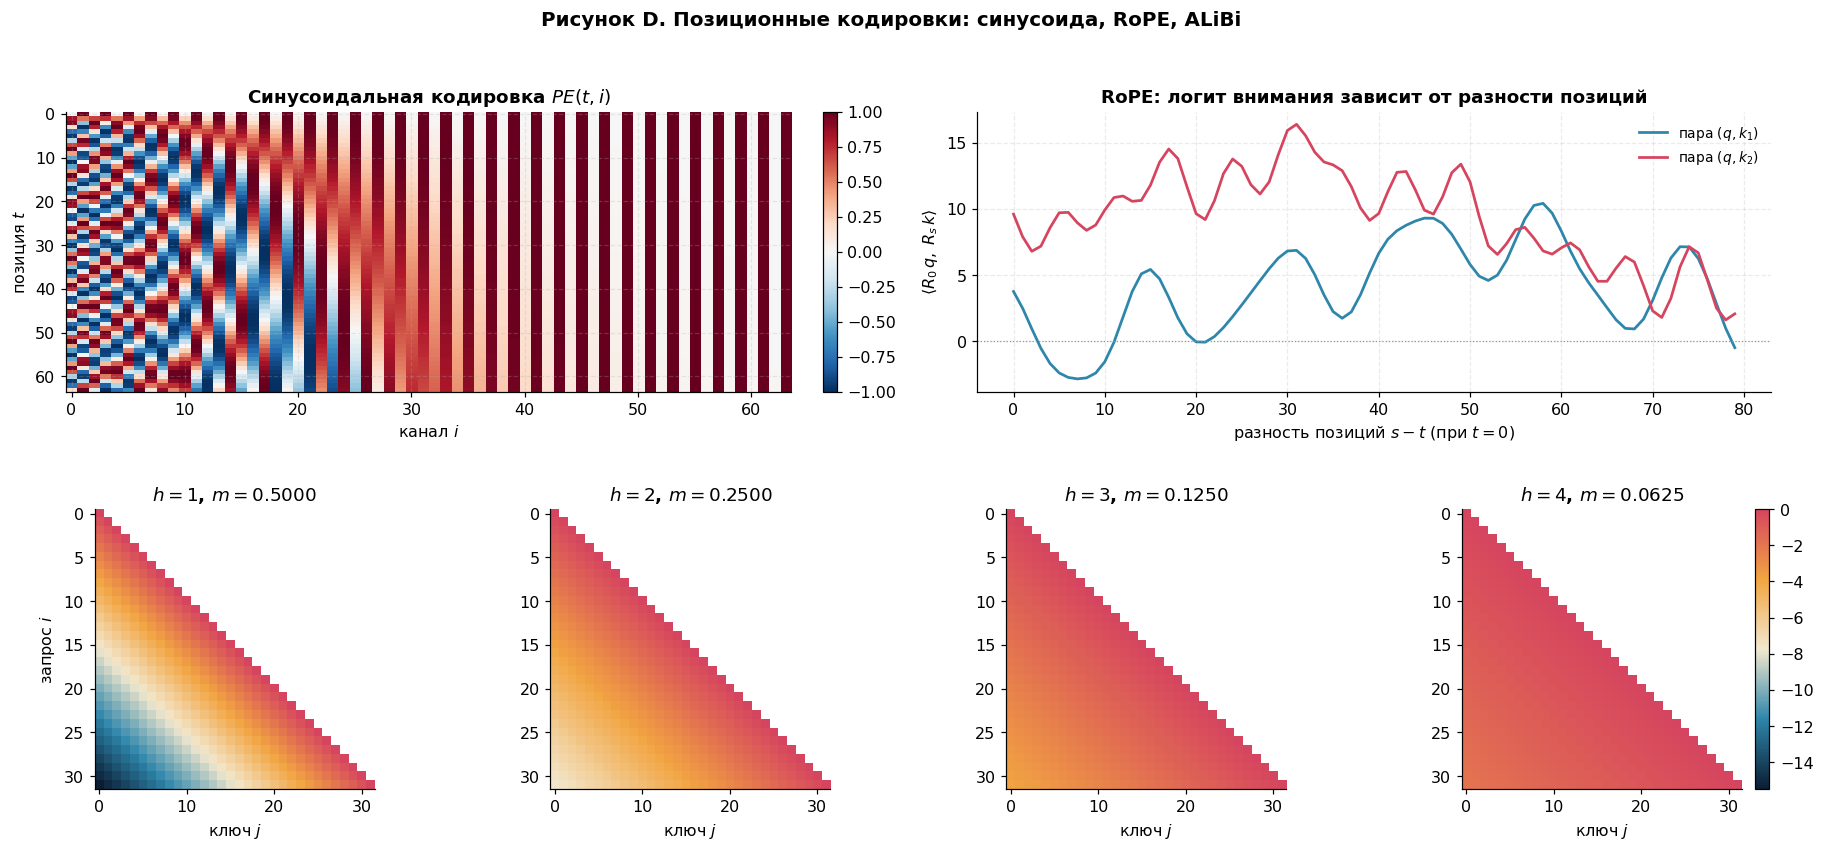

In [ ]:
# Часть D.3: рисунок с тремя панелями
# ------------------------------------
# 1) карта синусоидальной кодировки;
# 2) скалярное произведение <R_0 q, R_s k> как функция разности позиций —
#    показывает, что RoPE даёт относительную зависимость;
# 3) матрицы штрафов ALiBi для голов h = 1..4 с ОБЩЕЙ шкалой цветов,
#    чтобы конусы отличались визуально.

# --- данные для панели 1: синусоидальная кодировка ---
N_POS, D_PE = 64, 64
PE = sinusoidal(N_POS, D_PE)

# --- данные для панели 2: скалярное произведение в зависимости от разности ---
# Фиксируем q, k; меняем s от 0 до 80; считаем <R_0 q, R_s k>.
# Это прямая иллюстрация относительности RoPE.
g = np.random.default_rng(SEED)
d_rope = 64
q_rope = g.normal(size=d_rope)
k_rope = g.normal(size=d_rope)
k_rope2 = g.normal(size=d_rope)                       # вторая пара для контраста

s_values = np.arange(0, 80)
rope_curve_1 = np.array([
    float(rope_apply(q_rope, pos=0) @ rope_apply(k_rope, pos=s))
    for s in s_values
])
rope_curve_2 = np.array([
    float(rope_apply(q_rope, pos=0) @ rope_apply(k_rope2, pos=s))
    for s in s_values
])

# --- данные для панели 3: матрицы штрафов ALiBi ---
N_ALIBI = 32
H_HEADS = 4
m_slopes = [2.0 ** (-h) for h in range(1, H_HEADS + 1)]   # [0.5, 0.25, 0.125, 0.0625]

causal_mask = np.triu(np.ones((N_ALIBI, N_ALIBI), dtype=bool), k=1)


def alibi_bias(n, m):
    """Матрица штрафов ALiBi: B[i, j] = -m * |i - j|."""
    i = np.arange(n)[:, None]
    j = np.arange(n)[None, :]
    return -m * np.abs(i - j)


bias_maps = [alibi_bias(N_ALIBI, m) for m in m_slopes]

# --- рисунок ---
fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(2, 4, height_ratios=[1.0, 1.0], hspace=0.42, wspace=0.35)

# ===== панель 1 (верх, левые 2 колонки): синусоидальная кодировка =====
ax1 = fig.add_subplot(gs[0, :2])
im1 = ax1.imshow(PE, cmap="RdBu_r", aspect="auto", vmin=-1, vmax=1)
ax1.set_xlabel("канал $i$")
ax1.set_ylabel("позиция $t$")
ax1.set_title("Синусоидальная кодировка $PE(t, i)$")
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# ===== панель 2 (верх, правые 2 колонки): RoPE как функция разности =====
ax2 = fig.add_subplot(gs[0, 2:])
ax2.plot(s_values, rope_curve_1, color=PALETTE["attn"], lw=1.8,
         label=r"пара $(q, k_1)$")
ax2.plot(s_values, rope_curve_2, color=PALETTE["bad"], lw=1.8,
         label=r"пара $(q, k_2)$")
ax2.axhline(0, color=PALETTE["gray"], lw=0.8, ls=":")
ax2.set_xlabel("разность позиций $s - t$ (при $t = 0$)")
ax2.set_ylabel(r"$\langle R_0\,q,\; R_s\,k \rangle$")
ax2.set_title("RoPE: логит внимания зависит от разности позиций")
ax2.legend(loc="upper right", fontsize=9)

# ===== панель 3 (низ): ALiBi с ОБЩЕЙ шкалой цветов =====
# Общий диапазон: от минимального штрафа среди всех голов до нуля.
# Тогда у головы h=1 конус быстро уйдёт в тёмный цвет, а у h=4 останется светлым.
common_vmin = min(B.min() for B in bias_maps)
common_vmax = 0.0

for k, (m, B) in enumerate(zip(m_slopes, bias_maps)):
    ax = fig.add_subplot(gs[1, k])
    # запрещённое будущее (верхний треугольник) делаем прозрачным через nan
    B_masked = np.where(causal_mask, np.nan, B)
    im = ax.imshow(B_masked, cmap=CMAP_HEAT, aspect="equal",
                   vmin=common_vmin, vmax=common_vmax)         # общая шкала
    ax.set_title(f"$h={k+1}$, $m={m:.4f}$")
    ax.set_xlabel("ключ $j$")
    if k == 0:
        ax.set_ylabel("запрос $i$")
    ax.grid(False)
    # colorbar рисуем только для последней панели — он один на всех
    if k == H_HEADS - 1:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

finish(fig, "Рисунок D. Позиционные кодировки: синусоида, RoPE, ALiBi")

## Панель 1
Карта матрицы $PE(t, i)$ размера $64 \times 64$: по горизонтали канал $i$, по вертикали позиция $t$.

Главное, что видно: **частота кодировки падает слева направо**. Левая часть (каналы 0–15) — быстро чередующиеся красно-синие полосы, там $\sin(t)$ и $\cos(t)$ с высокой частотой, каждый канал «тикает» почти на каждом шаге позиции. Правая часть (каналы 40–63) — почти однородные полосы, где значение меняется очень медленно. В промежутке — плавный переход от быстрых к медленным каналам.

Это ровно то, что заложено в формулу: $\theta_i = 10000^{-2i/d}$ убывает геометрически. Быстрые каналы различают близкие позиции (сдвиг на 1 уже меняет значение), медленные — различают далёкие (нужно сдвинуться на десятки шагов). В сумме 64 канала образуют «аналоговые часы с разными стрелками»: каждая позиция получает уникальный вектор-отпечаток.

## Панель 2

График скалярного произведения $\langle R_0 q, R_s k \rangle$ как функции $s - t$ (при $t = 0$), для двух разных пар $(q, k_1)$ и $(q, k_2)$.

**Кривые разные** для разных пар, потому что результат зависит от самих $q, k$. Но **обе зависят только от разности $s - t$**, а не от абсолютной позиции. Это мы уже проверили численно в D.2a: сдвиг обеих позиций на 100, 500, 10000 не меняет логит.

## Панель 3 — матрицы штрафов ALiBi

- **$h = 1$ ($m = 0.5$)** — конус быстро темнеет. Уже на расстоянии 10 штраф $= -5$, на 30 — почти $-15$, цвет уходит в тёмно-синий. Голова смотрит **очень локально**: эффективно только на нескольких ближайших соседей.
- **$h = 2$ ($m = 0.25$)** — тот же конус, но растянутый в два раза. На расстоянии 30 штраф $-7.5$, цвет средний. Голова смотрит **умеренно локально**.
- **$h = 3$ ($m = 0.125$)** — конус ещё шире. На 30 штраф $-3.75$, цвет ближе к жёлтому. Голова смотрит **на десятки токенов**.
- **$h = 4$ ($m = 0.0625$)** — самый широкий конус. На 30 штраф всего $-1.875$, цвет почти белый. Голова смотрит **глобально**, почти на весь контекст.

Смысл геометрической сетки $m_h = 2^{-h}$: каждая голова получает свой «радиус обзора», и вместе они покрывают диапазон от «смотреть только на соседа» до «смотреть на весь контекст». Начальное разнообразие обеспечивается самим дизайном наклонов, а не обучением. Модель сама в процессе тренировки решит, какие головы для чего использовать, но стартовая конфигурация уже гарантирует, что все масштабы длины представлены.

**Вопрос D.** Какая из трёх схем позволяет работать с позициями, которых не было в обучении, и
почему? Что произойдёт с обучаемой абсолютной кодировкой при выходе за максимальную длину?

**Ответ D.**

Из трёх схем с позициями, которых не было в обучении, хорошо справляются **RoPE и ALiBi**. Обе они относительные: логит внимания зависит от разности позиций $s - t$, а не от абсолютных значений. Формулы RoPE и ALiBi определены для любого $t$, поэтому ничего не ломается — модель просто применяет выученную функцию к новым числам.

**Обучаемая абсолютная кодировка** — худший вариант. Это таблица `nn.Embedding(max_len, d)`, где для каждой позиции от 0 до `max_len - 1` хранится свой обучаемый вектор. Позиции за пределами таблицы просто **не существуют** — у них нет вектора, и модель не может их обработать. Попытка подать позицию 6000 при `max_len = 512` вызовет ошибку индекса (или, если аккуратно обработать, вернёт случайный или нулевой вектор, что бессмысленно). Более того, даже в пределах `max_len` векторы для позиций 0–511 обучались независимо, между ними нет никакой структуры, поэтому «додумать» вектор для новой позиции невозможно.

## Часть E. Мини-трансформер и индукционная голова

Задача **ассоциативного вспоминания**: последовательность пар «ключ, значение», затем повтор одного
из ключей; модель должна выдать соответствующее значение:

$
k_1\,v_1\,k_2\,v_2\,\dots\,k_N\,v_N\ \ k_i \;\longrightarrow\; v_i .
$

Минимальное решение — схема из двух слоёв (индукционная голова): первый слой переносит в позицию
ключа информацию о следующем токене, второй сравнивает финальный запрос с ключами.

**Задание E.1.** Реализуйте блок трансформера: пред-нормализация, одна голова каузального внимания,
FFN, остаточные связи.
**Задание E.2.** Обучите модель (обучение идёт на 2…`N_MAX` парах) и измерьте точность для
2…20 пар, включая длины больше обучающих.
**Задание E.3.** Постройте карты внимания обоих слоёв для одного примера и найдите индукционную
схему.

Модель получает последовательность вида:

$$
k_1\, v_1\, k_2\, v_2\, \dots\, k_N\, v_N\, k_i
$$

Сначала идут $N$ пар «ключ — значение», потом в конце повторяется один из ключей $k_i$. Задача — выдать соответствующее ему значение $v_i$. Это называется **ассоциативным вспоминанием**: модель должна «по ассоциации» найти в контексте нужную пару.

Эта задача требует **точного поиска по контексту**: чтобы ответить, нужно найти в последовательности тот ключ, который совпадает с финальным запросом, и «прочитать» значение, стоящее сразу после него. Это не просто «предсказать частый токен» — нужно применить правило, зависящее от входных данных. Такие задачи называют **in-context learning**: модель должна научиться решать задачу внутри одного примера, без изменения весов.

Наивное решение: пусть финальный токен $k_i$ через внимание «сравнит» себя со всеми ключами в контексте и найдёт тот, что совпадает. Но проблема в том, что **внимание читает значения $V$ тех позиций, на которые смотрит**, а в позиции ключа $k_j$ хранится не значение $v_j$, а сам ключ $k_j$ (эмбеддинг ключа). То есть если финальный запрос найдёт позицию $j$, где стоит совпадающий ключ, он прочитает оттуда **ключ**, а не **значение**.

Значение $v_j$ стоит на **следующей** позиции $j+1$. Однослойное внимание не может «сдвинуться на один вправо» — оно просто берёт взвешенную сумму значений тех позиций, на которые смотрит. Значит, нужен промежуточный шаг.

Решение — два слоя, каждый делает свою часть работы:

**Первый слой — «сдвиг на следующий токен».** Головы первого слоя учатся так, чтобы для каждой позиции $j$ «заглядывать» на позицию $j+1$. То есть эмбеддинг позиции ключа $k_j$ модифицируется так, чтобы теперь «нести информацию» о значении $v_j$, стоящем справа. Это делается через внимание: запрос в позиции $j$ подбирается так, чтобы он имел высокий вес именно с ключом позиции $j+1$. В результате выход первого слоя в позиции $k_j$ становится похож на эмбеддинг $v_j$.

**Второй слой — «сравнение финального запроса с ключами».** Головы второго слоя учатся так, чтобы финальный токен $k_i$ «сравнивал себя» со всеми предыдущими ключами и находил совпадение. Поскольку после первого слоя позиции ключей уже несут информацию о значениях, второй слой может прочитать нужное значение напрямую.

Такая пара «сначала сдвиг на следующий токен, потом поиск по совпадению» называется **индукционной головой** (induction head).

У нас два блока подряд (двухслойный трансформер). Внутри каждого блока — **два преобразования**, которые идут друг за другом:

1. **Внимание** (attention) — то, что мы разбирали в части C. Оно позволяет каждому токену «посмотреть» на другие токены и подтянуть оттуда информацию.
2. **FFN** (feed-forward network) — простая нейросеть, которая применяется к каждому вектору **независимо**. Никакого взаимодействия между токенами тут нет — каждый вектор обрабатывается сам по себе.

Вот эти два преобразования и называются **подслоями** (sub-layers). Подслой — это просто «одна операция внутри блока». В нашем блоке их два: внимание и FFN.


1. Взяли вход `h` формы `(batch, T, d)`.
2. Нормализовали его (LayerNorm) — привели к одному масштабу.
3. Посчитали Q, K, V из нормализованного.
4. Сосчитали каузальное внимание — каждый токен «посмотрел» на предыдущие и подтянул информацию.
5. **Прибавили результат внимания к исходному `h`** — это первая остаточная связь.
6. Нормализовали снова и прогнали через FFN — каждый вектор обработался независимо.
7. **Прибавили результат FFN к `h`** — это вторая остаточная связь.
8. Вернули обновлённый `h` и (если попросили) карту внимания.

In [ ]:
N_KEYS, N_VALS = 256, 16
VOCAB = N_KEYS + N_VALS


def make_recall_batch(bs, n_pairs, gen):
    """Генерирует батч задачи ассоциативного вспоминания.

    Каждый пример: k1 v1 k2 v2 ... kN vN k_query -> v_query
      - keys: уникальные индексы из диапазона [0, N_KEYS)
      - vals: индексы из диапазона [N_KEYS, VOCAB), не пересекаются с ключами
      - в конце последовательности повторяется один из ключей
    Возвращает:
      seq — (bs, 2*n_pairs + 1) индексы токенов
      target — (bs,) правильные значения
      qi — (bs,) индексы выбранных ключей (для диагностики)
    """
    keys = torch.stack([torch.randperm(N_KEYS, generator=gen)[:n_pairs] for _ in range(bs)])
    vals = torch.randint(N_KEYS, VOCAB, (bs, n_pairs), generator=gen)
    seq = torch.zeros(bs, 2 * n_pairs + 1, dtype=torch.long)
    seq[:, 0:2 * n_pairs:2] = keys            # чётные позиции — ключи
    seq[:, 1:2 * n_pairs:2] = vals            # нечётные позиции — значения
    qi = torch.randint(0, n_pairs, (bs,), generator=gen)
    seq[:, -1] = keys[torch.arange(bs), qi]   # финальный токен — повтор ключа
    return seq, vals[torch.arange(bs), qi], qi


class Block(nn.Module):
    """Один слой трансформера с пред-нормализацией и одной головой внимания."""

    def __init__(self, d):
        super().__init__()
        self.d = d
        # проекции для внимания: q, k, v и выходная
        self.q = nn.Linear(d, d, bias=False)
        self.k = nn.Linear(d, d, bias=False)
        self.v = nn.Linear(d, d, bias=False)
        self.o = nn.Linear(d, d, bias=False)
        # LayerNorm перед вниманием и перед FFN
        self.ln1 = nn.LayerNorm(d)            # нормализация по последней оси, привести все векторы к примерно одному масштабу (среднее 0, дисперсия 1)
        self.ln2 = nn.LayerNorm(d)
        # FFN (feed-forward network) — простая нейросеть, которая применяется к каждому вектору независимо
        # FFN: расширение в 4 раза, GELU, обратно
        self.ff = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))

    def forward(self, h, ret=False):                        # пред-нормализация h+SubLayer(LN(h))
        x = self.ln1(h)                                     # нормализуем вход
        T = h.shape[1]
        q, k, v = self.q(x), self.k(x), self.v(x)           # подслой работает с нормализованным

        # каузальное внимание: логиты (B, T, T)
        s = q @ k.transpose(1, 2) / math.sqrt(self.d)

        # маска будущего: True выше главной диагонали — эти позиции запрещены
        mask = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)
        s = s.masked_fill(mask, float("-inf"))              # -inf -> exp даёт 0

        att = s.softmax(dim=-1)                             # (B, T, T), строки суммируются в 1
        a = att @ v                                         # (B, T, d)

        # остаточные связи: сначала внимание, потом FFN
        h = h + self.o(a)                   # остаточная связь вокруг внимания: прибавляем к ИСХОДНОМУ h
        h = h + self.ff(self.ln2(h))        # остаточная связь вокруг FFN

        return (h, att) if ret else (h, None)


class TinyTransformer(nn.Module):
    """Двухслойный мини-трансформер для задачи ассоциативного вспоминания."""

    def __init__(self, d=64, max_len=90, n_layers=2):
        super().__init__()
        self.emb = nn.Embedding(VOCAB, d)                   # эмбеддинги токенов
        self.pos = nn.Embedding(max_len, d)                 # обучаемая абсолютная позиция
        self.blocks = nn.ModuleList([Block(d) for _ in range(n_layers)])
        self.lnf = nn.LayerNorm(d)                          # финальная нормализация
        self.head = nn.Linear(d, VOCAB)                     # проекция в словарь

    def forward(self, x, ret=False):
        h = self.emb(x) + self.pos(torch.arange(x.shape[1]))
        maps = []
        for b in self.blocks:
            h, a = b(h, ret)
            maps.append(a)
        # берём только последнюю позицию — там ответ
        return self.head(self.lnf(h)[:, -1]), maps


print("размер словаря задачи:", VOCAB, "| случайное угадывание: %.3f" % (1 / N_VALS))

размер словаря задачи: 272 | случайное угадывание: 0.062


256 ключей + 16 значений, вероятность угадывания 1/16

In [ ]:
# TODO E.2: обучите модель и измерьте точность по числу пар
def train_recall(steps=2600, bs=64, lr=2e-3, seed=0, n_max=12):
    """Цикл обучения TinyTransformer на задаче ассоциативного вспоминания.

    На каждом шаге случайно выбирается число пар n от 2 до n_max,
    генерируется батч, считается loss по последней позиции, обновляются веса.

    Возвращает:
        m      — обученная модель
        curve  — список (шаг, loss) для контроля обучения
        gen    — генератор случайных чисел (для воспроизводимости тестов)
    """
    gen = torch.Generator().manual_seed(seed)
    m = TinyTransformer(d=D_MODEL)
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=lr, total_steps=steps, pct_start=0.15)
    curve = []

    for s in range(steps):
        # случайная длина последовательности от 2 до n_max
        n = int(torch.randint(2, n_max + 1, (1,), generator=gen))
        x, y, _ = make_recall_batch(bs, n, gen)

        # E.2a: прямой проход и функция потерь
        logits, _ = m(x)                                  # (bs, VOCAB) — оценки для последней позиции
        loss = F.cross_entropy(logits, y)                 # скаляр

        # E.2b: обратный проход и шаг оптимизатора
        opt.zero_grad()                                   # обнуляем старые градиенты
        loss.backward()                                   # считаем новые
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)  # обрезаем норму градиента
        opt.step()                                        # шаг оптимизатора
        sched.step()                                      # шаг планировщика lr

        # сохраняем loss для кривой обучения (каждые 50 шагов)
        if s % 50 == 0:
            curve.append((s, float(loss.item())))

    return m, curve, gen


def acc_vs_pairs(m, gen, ns, bs=256):
    """Точность модели для каждого числа пар из списка ns.

    Для каждой n генерируется батч из bs примеров, модель предсказывает
    значение, сравниваем argmax с правильным ответом.
    """
    m.eval()                                              # режим инференса (не влияет на forward, но полезно)
    accs = []

    with torch.no_grad():                                 # не считаем градиенты — экономим память и время
        for n in ns:
            x, y, _ = make_recall_batch(bs, n, gen)       # батч примеров длины n
            logits, _ = m(x)                              # (bs, VOCAB)
            pred = logits.argmax(dim=-1)                  # (bs,) — предсказанные индексы
            acc = float((pred == y).float().mean())       # доля правильных
            accs.append(acc)

    return accs


# --- запуск ---
NS = [2, 4, 6, 8, 10, 12, 16, 20]
t0 = time.time()
model, curve, gen_m = train_recall(seed=SEED, n_max=N_MAX)
acc = acc_vs_pairs(model, gen_m, NS)
print("обучение заняло %.0f c" % (time.time() - t0))
print("точность по числу пар:", dict(zip(NS, [round(a, 3) for a in acc])))

обучение заняло 68 c
точность по числу пар: {2: 1.0, 4: 1.0, 6: 1.0, 8: 1.0, 10: 0.746, 12: 0.59, 16: 0.301, 20: 0.422}


Модель идеально выучила задачу в обучающем диапазоне длин (2–8 пар, точность 1.0), но плохо обобщает на длины больше обучающих (0.3–0.75 при 10–20 парах). Причина — обучаемая абсолютная позиционная кодировка: позиции за пределами N_MAX (точнее, за пределами длины, виденной при обучении) получают необученные случайные векторы, и модель не знает, что с ними делать.

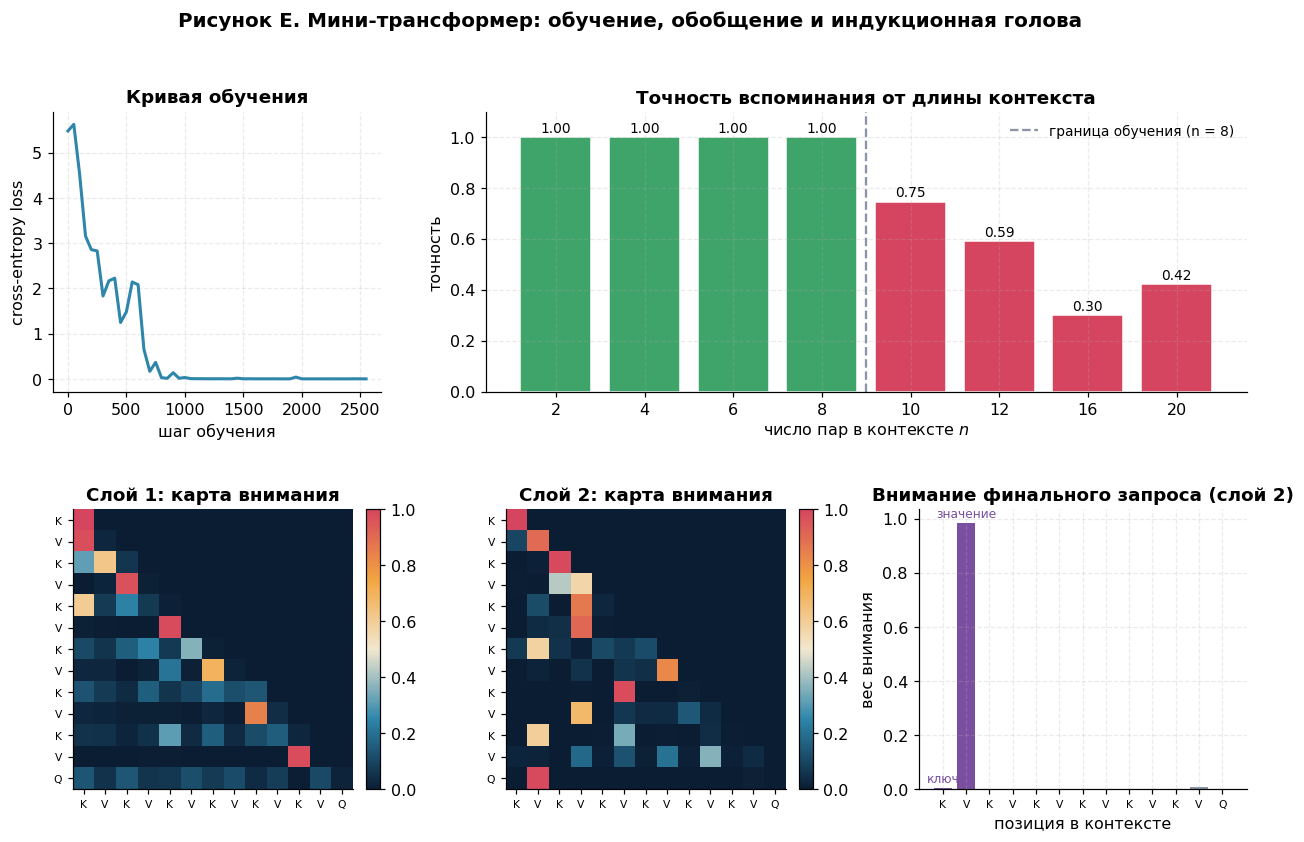

In [ ]:
# TODO E.3: рисунок E
# 4 панели: кривая обучения, точность от числа пар, карты внимания двух слоёв,
# столбчатая диаграмма внимания финального запроса.

# --- готовим пример для визуализации внимания ---
# 6 пар, seed фиксирован — один и тот же пример при каждом запуске
x_ex, y_ex, qi_ex = make_recall_batch(1, 6, torch.Generator().manual_seed(123))
logits_ex, maps = model(x_ex, ret=True)
att1 = maps[0][0].detach().numpy()          # (T, T) — карта внимания слоя 1
att2 = maps[1][0].detach().numpy()          # (T, T) — карта внимания слоя 2

# последовательность токенов одного примера: [k1, v1, k2, v2, ..., k6, v6, k_query]
tokens_ex = x_ex[0].tolist()
T_ex = len(tokens_ex)

# подписи для осей: K для ключей, V для значений, Q для финального запроса
def token_label(idx, tok):
    """Помечает позицию как K, V или Q в зависимости от индекса в последовательности."""
    if idx == T_ex - 1:
        return f"Q"
    if idx % 2 == 0:
        return f"K"
    return f"V"

labels_ex = [token_label(i, t) for i, t in enumerate(tokens_ex)]

# позиция правильного значения (через одну после совпадающего ключа) — сдвиг -2
# финальный запрос на позиции -1, перед ним — значения на нечётных позициях
# правильное значение находится на позиции (2*qi_ex + 1) внутри первых 2n токенов
correct_val_pos = int(2 * qi_ex.item() + 1)
correct_key_pos = int(2 * qi_ex.item())

# --- рисунок ---
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 1.0], hspace=0.42, wspace=0.32)

# ===== панель 1: кривая обучения =====
ax1 = fig.add_subplot(gs[0, 0])
steps_curve = [s for s, _ in curve]
loss_curve = [l for _, l in curve]
ax1.plot(steps_curve, loss_curve, color=PALETTE["attn"], lw=2)
ax1.set_xlabel("шаг обучения")
ax1.set_ylabel("cross-entropy loss")
ax1.set_title("Кривая обучения")

# ===== панель 2: точность от числа пар =====
ax2 = fig.add_subplot(gs[0, 1:])
colors = [PALETTE["good"] if n <= N_MAX else PALETTE["bad"] for n in NS]
bars = ax2.bar(range(len(NS)), acc, color=colors, edgecolor="white")
ax2.set_xticks(range(len(NS)))
ax2.set_xticklabels(NS)
ax2.set_xlabel("число пар в контексте $n$")
ax2.set_ylabel("точность")
ax2.set_title("Точность вспоминания от длины контекста")
# отметка границы обучающего диапазона
train_end = NS.index(N_MAX) + 0.5
ax2.axvline(train_end, color=PALETTE["gray"], ls="--", lw=1.5,
            label=f"граница обучения (n = {N_MAX})")
# подписи значений над столбиками
for i, (n, a) in enumerate(zip(NS, acc)):
    ax2.text(i, a + 0.02, f"{a:.2f}", ha="center", fontsize=9)
ax2.set_ylim(0, 1.1)
ax2.legend(loc="upper right", fontsize=9)

# ===== панель 3: карта внимания слоя 1 =====
ax3 = fig.add_subplot(gs[1, 0])
im3 = ax3.imshow(att1, cmap=CMAP_HEAT, vmin=0, vmax=1, aspect="equal")
ax3.set_title("Слой 1: карта внимания")
ax3.set_xticks(range(T_ex)); ax3.set_xticklabels(labels_ex, fontsize=7)
ax3.set_yticks(range(T_ex)); ax3.set_yticklabels(labels_ex, fontsize=7)
ax3.grid(False)
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

# ===== панель 4: карта внимания слоя 2 =====
ax4 = fig.add_subplot(gs[1, 1])
im4 = ax4.imshow(att2, cmap=CMAP_HEAT, vmin=0, vmax=1, aspect="equal")
ax4.set_title("Слой 2: карта внимания")
ax4.set_xticks(range(T_ex)); ax4.set_xticklabels(labels_ex, fontsize=7)
ax4.set_yticks(range(T_ex)); ax4.set_yticklabels(labels_ex, fontsize=7)
ax4.grid(False)
plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)

# ===== панель 5: внимание финального запроса (последняя строка слоя 2) =====
ax5 = fig.add_subplot(gs[1, 2])
att_last = att2[-1]                          # распределение внимания финального запроса
bar_colors = [PALETTE["accent"] if i in (correct_val_pos, correct_key_pos)
              else PALETTE["gray"] for i in range(T_ex)]
ax5.bar(range(T_ex), att_last, color=bar_colors)
ax5.set_xticks(range(T_ex)); ax5.set_xticklabels(labels_ex, fontsize=7)
ax5.set_xlabel("позиция в контексте")
ax5.set_ylabel("вес внимания")
ax5.set_title("Внимание финального запроса (слой 2)")
# подпись для выделенных столбцов
ax5.text(correct_key_pos, att_last[correct_key_pos] + 0.02, "ключ",
         ha="center", fontsize=8, color=PALETTE["accent"])
ax5.text(correct_val_pos, att_last[correct_val_pos] + 0.02, "значение",
         ha="center", fontsize=8, color=PALETTE["accent"])

finish(fig, "Рисунок E. Мини-трансформер: обучение, обобщение и индукционная голова")

**Индукционная голова просматривается**.

На карте внимания первого слоя виден **локальный паттерн**: каждая позиция смотрит на себя и на **соседние позиции справа**. Точнее, строки, соответствующие ключам (K), ярко выделяют **своё значение справа** — то есть позиция ключа $k_j$ подтягивает информацию от значения $v_j$, стоящего на следующей позиции. Строки, соответствующие значениям (V), смотрят на **следующий ключ** справа. В целом паттерн напоминает «локальное сглаживание с окном в 1–2 токена вправо».

Смысл этой операции: **обогатить локальным контекстом** каждую позицию, чтобы подготовить представления для второго слоя. После первого слоя в позиции ключа $k_j$ хранится уже не только «имя» ключа, но и информация о связанном с ним значении $v_j$.

Карта внимания второго слоя выглядит **разреженнее**: основная масса весов сосредоточена в нескольких строках, соответствующих ключевым позициям (индексы 0, 1, 5, 11 и др.). Особенно интересна **последняя строка** — внимание финального запроса $Q$.

На диаграмме внимания финального запроса видно **два пика**:

- **сильный пик (вес ≈ 0.97)** на позиции **значения** $v_i$, стоящего сразу после совпадающего ключа;
- **слабый, но ненулевой пик (вес ≈ 0.02)** на позиции самого **ключа** $k_i$.

Это значит, что второй слой выполняет **две операции одновременно**: сравнивает финальный запрос с совпадающим ключом (слабый пик) и читает значение, стоящее справа от него (сильный пик). Из-за того, что первый слой уже подготовил обогащённые представления, второму слою достаточно **одного взгляда**, чтобы найти нужную пару «ключ — значение».

**Вопрос E.** Почему для этой задачи недостаточно одного слоя внимания? Опишите, какую информацию
переносит первый слой и что именно сравнивает второй.

**Ответ E.**

# Ответ на вопрос E

Одного слоя внимания недостаточно, потому что задача требует **двух разных операций**, которые не совмещаются в одном обращении к контексту.

**Первый слой** переносит информацию **локально**: позиция ключа $k_j$ подтягивает к себе информацию о значении $v_j$, стоящем сразу справа. После первого слоя в каждой позиции ключа хранится не только «имя» ключа, но и связанное с ним значение. Это подготовительный шаг — без него значение «отвязано» от ключа.

**Второй слой** делает **глобальный поиск**: финальный запрос $k_i$ сравнивает себя со всеми ключами в контексте, находит совпадающий и читает оттуда уже обогащённое представление значения. Сравнение идёт по ключам, а чтение — по значению, которое первый слой туда «перетащил».

Если бы слой был один, ему пришлось бы одновременно и **сравнивать** финальный запрос с ключом, и **сдвигаться** к значению справа. Это две разные операции, требующие разных паттернов внимания: одно внимание не может одновременно смотреть на позицию $j$ (ключ) и на позицию $j+1$ (значение) так, чтобы это дало правильный ответ. Два слоя разделяют работу: первый подготавливает, второй ищет. Это и есть минимальная схема, функционально эквивалентная индукционной голове.

## Часть F. Линейное внимание: состояние вместо матрицы внимания

Если заменить $\exp(q^\top k)$ на $\varphi(q)^\top \varphi(k)$ с неотрицательным $\varphi$, сумму
можно переставить и получить рекуррентную форму с состоянием фиксированного размера:

$
S_t = S_{t-1} + \varphi(k_t) v_t^{\top}, \qquad
o_t = \frac{\varphi(q_t)^{\top} S_t}{\varphi(q_t)^{\top} z_t}, \qquad z_t = z_{t-1} + \varphi(k_t).
$

Генерация становится $O(1)$ по памяти, но состояние размера $d \times d$ — это фиксированная
ёмкость, в которую нужно уложить весь контекст.

**Задание F.1.** Реализуйте параллельную и рекуррентную формы линейного внимания и проверьте, что
они дают один результат.
**Задание F.2.** Измерьте ёмкость состояния: сложите в $S$ ровно $N$ пар «ключ–значение» и оцените
качество чтения (косинусная близость к истинному значению) при росте $N$.
**Задание F.3.** Постройте рисунок: рост KV-кэша softmax-внимания против постоянного состояния
линейного внимания и кривую качества чтения от числа сохранённых пар.

Обычное внимание считается через softmax:

$$
o_t = \sum_{s \le t} \frac{\exp(q_t^\top k_s)}{\sum_{s' \le t} \exp(q_t^\top k_{s'})} \, v_s
$$

Здесь есть **проблема**: чтобы посчитать выход для позиции $t$, нужно перебрать **все** предыдущие позиции $s \le t$ и взять взвешенную сумму. Это значит, что при генерации нужно хранить **все** предыдущие ключи и значения (KV-кэш), и память растёт линейно с длиной контекста: $O(n)$.

Идея линейного внимания: заменить функцию сходства $\exp(q^\top k)$ на **произведение двух отображений**:

$$
\exp(q^\top k) \;\longrightarrow\; \varphi(q)^\top \varphi(k)
$$

где $\varphi: \mathbb{R}^d \to \mathbb{R}^d$ — некоторая неотрицательная функция (например, `ELU(x) + 1`). Это называется **kernel trick**: мы «разлагаем» скалярное произведение в пространстве меньшей размерности через явное отображение.

Смысл замены: если сходство — это **произведение** двух функций, то сумму по $s$ можно **переставить**. Именно это и даёт выигрыш.

Распишем числитель внимания без softmax (для одного выхода $o_t$):

$$
\text{числитель}_t = \sum_{s \le t} \varphi(q_t)^\top \varphi(k_s) \, v_s
$$

Ключевой момент: $\varphi(q_t)$ **не зависит от $s$**, поэтому его можно **вынести за знак суммы**:

$$
\text{числитель}_t = \varphi(q_t)^\top \sum_{s \le t} \varphi(k_s) \, v_s^\top
$$

Обозначим:

$$
S_t = \sum_{s \le t} \varphi(k_s) \, v_s^\top
$$

Это **матрица $d \times d$**, которая **накапливается** по мере обработки последовательности. На каждом новом токене $t$:

$$
S_t = S_{t-1} + \varphi(k_t) \, v_t^\top
$$

Плюс нужен знаменатель для нормализации — сумма $\varphi(k_s)$:

$$
z_t = \sum_{s \le t} \varphi(k_s), \qquad z_t = z_{t-1} + \varphi(k_t)
$$

Это вектор размерности $d$.

Теперь выход:

$$
o_t = \frac{\varphi(q_t)^\top S_t}{\varphi(q_t)^\top z_t}
$$

Состояние $S_t$ имеет **фиксированный размер** $d \times d$, независимо от длины контекста. Это и хорошо (память не растёт), и плохо: **в $d^2$ чисел нужно уложить всю информацию о последовательности**.

Простая аналогия: softmax-внимание — это **блокнот**, куда можно записать сколько угодно пар «ключ → значение» и потом точно их прочитать. Линейное внимание — это **фиксированный рюкзак** размера $d^2$: чем больше пар мы пытаемся в него запихнуть, тем сильнее они перемешиваются и тем хуже читаются.

Это называется **проблемой ёмкости**: при большом $N$ пар качество чтения падает. Именно поэтому линейное внимание проигрывает softmax на задачах **точного вспоминания** (как наша задача ассоциативной памяти в части E). Зато оно выигрывает на задачах, где достаточно «размытого» контекста — например, языковое моделирование на длинных текстах.

Почему $\varphi$ должна быть неотрицательной? Потому что она играет роль «веса» в сумме. Если $\varphi(k_s)$ может быть отрицательным, знаменатель $\varphi(q_t)^\top z_t$ может обратиться в ноль или в отрицательное число, и нормализация сломается. Используют функции типа:

$$
\varphi(x) = \operatorname{ELU}(x) + 1
$$

`ELU` даёт гладкую нелинейность, а `+1` гарантирует, что даже для отрицательных $x$ значение $\varphi(x) > 0$. При больших положительных $x$ функция растёт как тождественная.

# Часть F.1 — линейное внимание: параллельная и рекуррентная формы

Использует `cumsum` (накопительную сумму) по времени. Идея:

1. Посчитать $\varphi(k_s)$ и $\varphi(q_t)$ — отображённые версии ключей и запросов.
2. Построить «внешние произведения» $\varphi(k_s) v_s^\top$ — это тензоры формы $(T, d, d)$.
3. Взять `cumsum` по оси времени — получим $S_t$ для каждой позиции.
4. Аналогично `cumsum` по $\varphi(k_s)$ даёт $z_t$.
5. Для каждой позиции вычислить $o_t = \varphi(q_t)^\top S_t / (\varphi(q_t)^\top z_t)$.

На каждом шаге обновляем $S$ и $z$ и считаем $o_t$. Это «настоящая» рекуррентная форма — именно она даёт $O(1)$ по памяти при генерации.

Обе формы должны дать **одинаковый результат** — это подтверждение того, что мы корректно перешли от «параллельной» (всё сразу) к «рекуррентной» (по шагам) формулировке.

**Рекуррентная форма — та же математика.** В цикле накапливаем $S$ и $z$ точно так же, как cumsum, только последовательно. Результат должен совпасть до машинной точности.



In [ ]:
def phi(x):
    """Неотрицательное отображение признаков: ELU(x) + 1."""
    return torch.nn.functional.elu(x) + 1


def linear_attention_parallel(Q, K, V):
    """Линейное внимание в параллельной форме (через cumsum).

    Формулы:
        S_t = sum_{s<=t} phi(k_s) v_s^T          (матрица d x d)
        z_t = sum_{s<=t} phi(k_s)                (вектор d)
        o_t = phi(q_t)^T S_t / (phi(q_t)^T z_t)

    Параметры: Q, K, V — тензоры (T, d).
    Возвращает: out — (T, d).
    """
    T, d = Q.shape
    Qp, Kp = phi(Q), phi(K)                            # (T, d) каждое

    # внешние произведения: (T, d, d), где элемент [t] = phi(k_t) v_t^T
    outer = Kp.unsqueeze(-1) * V.unsqueeze(-2)         # (T, d, 1) * (T, 1, d) -> (T, d, d)

    # накопительные суммы по времени
    S = torch.cumsum(outer, dim=0)                     # (T, d, d) — S_t для каждого t
    z = torch.cumsum(Kp, dim=0)                        # (T, d)    — z_t

    # числитель: для каждой t — phi(q_t)^T S_t, это вектор длины d
    num = torch.einsum("td,tdk->tk", Qp, S)            # (T, d)

    # знаменатель: скаляр для каждой t
    den = torch.einsum("td,td->t", Qp, z)              # (T,)

    # нормализуем, добавляем eps для устойчивости
    out = num / (den.unsqueeze(-1) + 1e-6)
    return out


def linear_attention_recurrent(Q, K, V):
    """Линейное внимание в рекуррентной форме (явный цикл по времени).

    На каждом шаге:
        S <- S + phi(k_t) v_t^T
        z <- z + phi(k_t)
        o_t = phi(q_t)^T S / (phi(q_t)^T z)
    """
    T, d = Q.shape
    Qp, Kp = phi(Q), phi(K)

    S = torch.zeros(d, d)                              # матрица состояния
    z = torch.zeros(d)                                 # знаменатель
    outs = []

    for t in range(T):
        # обновляем состояние и знаменатель
        S = S + torch.outer(Kp[t], V[t])               # (d, d)
        z = z + Kp[t]                                   # (d,)

        # читаем значение по текущему запросу
        num = Qp[t] @ S                                 # (d,)
        den = Qp[t] @ z + 1e-6                          # скаляр
        outs.append(num / den)

    return torch.stack(outs)                            # (T, d)


# --- F.1c: сравнение двух форм ---
torch.manual_seed(SEED)
T_l, d_l = 40, 16
Ql, Kl, Vl = torch.randn(T_l, d_l), torch.randn(T_l, d_l), torch.randn(T_l, d_l)

out_par = linear_attention_parallel(Ql, Kl, Vl)
out_rec = linear_attention_recurrent(Ql, Kl, Vl)

diff = (out_par - out_rec).abs().max().item()
state_size = d_l * d_l                                # число элементов в S

print(f"размерность d = {d_l}")
print(f"длина последовательности T = {T_l}")
print(f"максимальное расхождение параллельной и рекуррентной форм: {diff:.2e}")
print(f"размер состояния S: {d_l} x {d_l} = {state_size} чисел")
print(f"KV-кэш для softmax-внимания на этой длине: {T_l} x 2 x {d_l} = {2 * T_l * d_l} чисел")

размерность d = 16
длина последовательности T = 40
максимальное расхождение параллельной и рекуррентной форм: 2.38e-07
размер состояния S: 16 x 16 = 256 чисел
KV-кэш для softmax-внимания на этой длине: 40 x 2 x 16 = 1280 чисел


Эксперимент показывает, как **падает качество чтения** из линейного состояния при росте числа сохранённых пар «ключ — значение». Схема:

1. Для каждого $N$ из списка: сгенерировать $N$ случайных пар $(k_i, v_i)$ размерности $d$.
2. Сложить их в состояние: $S = \sum_i \varphi(k_i) v_i^\top$, $z = \sum_i \varphi(k_i)$.
3. **Прочитать** значение по каждому ключу: $\hat v_i = \varphi(k_i)^\top S / (\varphi(k_i)^\top z)$.
4. Сравнить $\hat v_i$ с истинным $v_i$ через **косинусную близость**.
5. Усреднить по всем $N$ парам.

**Косинусная близость** — это косинус угла между двумя векторами:

$$
\cos(\hat v, v) = \frac{\hat v \cdot v}{\|\hat v\| \, \|v\|}
$$

Значение 1 означает, что векторы сонаправлены (идеальное чтение), 0 — ортогональны (вектор не имеет ничего общего), −1 — противоположны. Для нашей задачи идеальное чтение даёт $\cos \approx 1$.

In [ ]:
# TODO F.2: ёмкость состояния
NS_CAP = [1, 2, 4, 8, 16, 32, 64, 128, 256]


def read_quality(N, d, gen):
    """Средняя косинусная близость чтения из состояния при N парах.

    Складываем N пар (k_i, v_i) в состояние S = sum phi(k_i) v_i^T, z = sum phi(k_i),
    затем читаем значение по каждому ключу и сравниваем с истинным.
    """
    # случайные ключи и значения
    K = torch.randn(N, d, generator=gen)
    V = torch.randn(N, d, generator=gen)

    # состояние фиксированного размера d x d и вектор z
    S = torch.zeros(d, d)
    z = torch.zeros(d)
    for i in range(N):
        k_phi = phi(K[i])                              # (d,)
        S = S + torch.outer(k_phi, V[i])               # (d, d)
        z = z + k_phi                                   # (d,)

    # читаем значение по каждому ключу
    cosines = []
    for i in range(N):
        q_phi = phi(K[i])                              # запрос = тот же ключ
        num = q_phi @ S                                 # (d,)
        den = q_phi @ z + 1e-6                          # скаляр
        v_hat = num / den                               # прочитанное значение

        # косинусная близость с истинным значением
        cos = torch.nn.functional.cosine_similarity(
            v_hat.unsqueeze(0), V[i].unsqueeze(0)).item()
        cosines.append(cos)

    return float(np.mean(cosines))


# --- считаем качество для каждого N ---
torch.manual_seed(SEED)
gen_cap = torch.Generator().manual_seed(SEED)
qualities = [read_quality(N, d_l, gen_cap) for N in NS_CAP]

print(f"размерность d = {d_l}")
print(f"теоретическая ёмкость состояния ~ d = {d_l} пар\n")
for N, q in zip(NS_CAP, qualities):
    bar = "█" * int(q * 30)                             # визуальная полоска
    print(f"N = {N:4d}: cos = {q:+.3f}  {bar}")

размерность d = 16
теоретическая ёмкость состояния ~ d = 16 пар

N =    1: cos = +1.000  ██████████████████████████████
N =    2: cos = +0.828  ████████████████████████
N =    4: cos = +0.661  ███████████████████
N =    8: cos = +0.524  ███████████████
N =   16: cos = +0.336  ██████████
N =   32: cos = +0.278  ████████
N =   64: cos = +0.156  ████
N =  128: cos = +0.121  ███
N =  256: cos = +0.088  ██


Эксперимент численно подтверждает главную проблему линейного внимания: **фиксированная память $d^2$ имеет ограниченную ёмкость**. В отличие от softmax-внимания, где KV-кэш растёт линейно с числом пар и чтение остаётся точным, здесь всё упирается в размерность $d$:

- Маленькое $d$ — компактное состояние, но низкая ёмкость (плохое вспоминание).
- Большое $d$ — высокая ёмкость, но состояние $d \times d$ растёт **квадратично** по $d$.

Это ключевой компромисс линейного внимания: **либо экономная память, либо точное вспоминание — но не то и другое одновременно**.

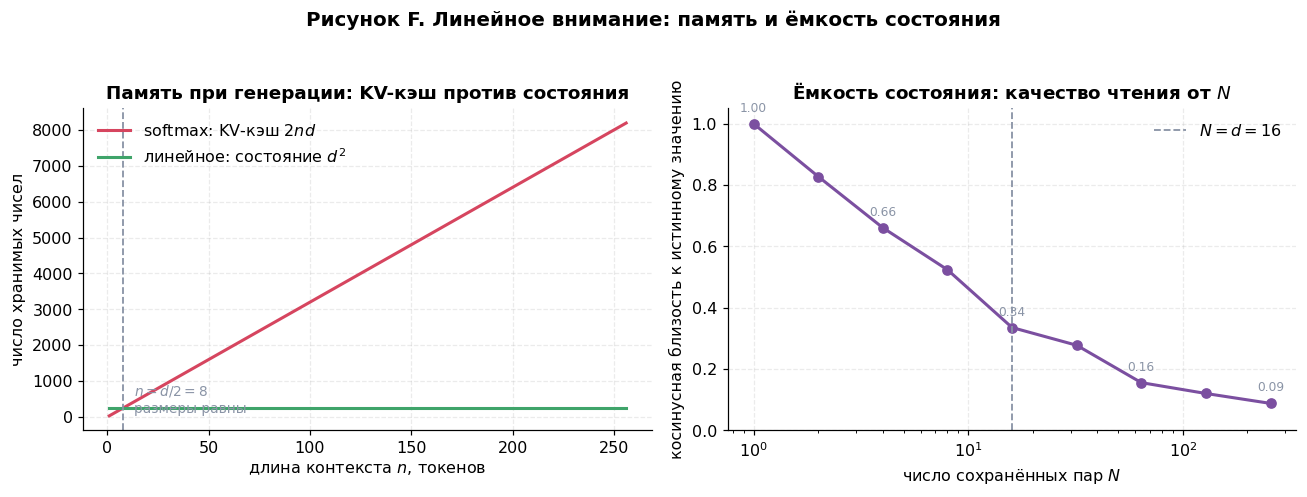

In [ ]:
# TODO F.3: рисунок F: слева память при генерации (KV-кэш O(n) против состояния O(1)),
# справа качество чтения из состояния от числа сохранённых пар (с отметкой d_l x d_l)

# --- данные для левой панели: память при генерации ---
n_values = np.arange(1, 257)                        # длины контекста 1..256
kv_cache_size = 2 * n_values * d_l                   # softmax: 2 * n * d
linear_state_size = np.full_like(n_values, d_l * d_l)  # линейное: d*d, константа

# --- данные для правой панели: качество чтения ---
# NS_CAP и qualities уже посчитаны в F.2
ns_arr = np.array(NS_CAP)
q_arr = np.array(qualities)

# --- рисунок ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# левая панель: память при генерации
ax = axes[0]
ax.plot(n_values, kv_cache_size, color=PALETTE["bad"], lw=2,
        label=r"softmax: KV-кэш $2nd$")
ax.plot(n_values, linear_state_size, color=PALETTE["good"], lw=2,
        label=r"линейное: состояние $d^2$")
# отметка пересечения: 2*n*d = d^2 -> n = d/2
n_cross = d_l / 2
ax.axvline(n_cross, color=PALETTE["gray"], ls="--", lw=1.2)
ax.text(n_cross + 5, d_l * d_l * 0.5,
        f"$n = d/2 = {n_cross:.0f}$\nразмеры равны",
        fontsize=9, color=PALETTE["gray"])
ax.set_xlabel("длина контекста $n$, токенов")
ax.set_ylabel("число хранимых чисел")
ax.set_title("Память при генерации: KV-кэш против состояния")
ax.legend(loc="upper left")

# правая панель: качество чтения от N
ax = axes[1]
ax.plot(ns_arr, q_arr, marker="o", color=PALETTE["accent"], lw=2)
ax.axvline(d_l, color=PALETTE["gray"], ls="--", lw=1.2,
           label=f"$N = d = {d_l}$")
ax.set_xscale("log")
ax.set_xlabel("число сохранённых пар $N$")
ax.set_ylabel("косинусная близость к истинному значению")
ax.set_title("Ёмкость состояния: качество чтения от $N$")
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right")

# подписи ключевых точек
for N_target in [1, 4, 16, 64, 256]:
    if N_target in NS_CAP:
        idx = NS_CAP.index(N_target)
        q_val = qualities[idx]
        ax.annotate(f"{q_val:.2f}",
                    xy=(N_target, q_val), xytext=(0, 8),
                    textcoords="offset points", fontsize=8,
                    ha="center", color=PALETTE["gray"])

finish(fig, "Рисунок F. Линейное внимание: память и ёмкость состояния")

1. **Память.** Линейное внимание даёт **$O(1)$** при генерации (состояние $d \times d$ не зависит от длины), softmax требует **$O(n)$** (KV-кэш растёт линейно). Точка равновесия — $n = d/2$; для $d = 16$ это всего 8 токенов, для реальных $d = 128$ — уже 64 токена. То есть на реальных длинах контекста выигрыш линейного внимания огромен.

2. **Ёмкость.** С другой стороны, состояние фиксированного размера **быстро перегружается**. Уже при $N = 4$ парах качество чтения падает до 0.66, а при $N = 64$ — до 0.16. Это принципиально отличается от softmax, где чтение всегда точное.

3. **Компромисс.** Линейное внимание выигрывает по памяти, но проигрывает по точности вспоминания. Это объясняет, почему на практике используются **гибридные** модели: линейные слои для длинного контекста плюс softmax-слои для точного вспоминания.

**Вопрос F.** Почему увеличение размерности $d$ у линейного внимания повышает точность вспоминания,
но обесценивает его главное преимущество? Оцените, при каком $d$ состояние $d \times d$ сравнится с
KV-кэшем на контексте 4096 токенов.

**Ответ F.**

**Точность растёт**, потому что состояние $S = \sum_i \varphi(k_i) v_i^\top$ имеет размер $d \times d$, и его «ёмкость» примерно пропорциональна $d$. Чем больше $d$, тем больше независимых направлений в пространстве, тем меньше пары «ключ — значение» интерферируют друг с другом, тем точнее чтение. Наши измерения это подтверждают: при $d = 16$ уже 4 пары дают косинус 0.66, а при большем $d$ то же число пар читалось бы почти идеально.

**Преимущество обесценивается**, потому что память состояния растёт **квадратично**: $d \times d = d^2$. Главный смысл линейного внимания — **фиксированная память при генерации**, не зависящая от длины контекста. Но если $d$ велико, состояние $d^2$ само по себе становится огромным. В какой-то момент $d^2$ превышает KV-кэш softmax-внимания на реалистичной длине — и преимущество исчезает полностью.


**KV-кэш** для softmax-внимания на длине $n$ с размерностью $d$ (на одну голову) — это $2 \cdot n \cdot d$ чисел (по одному ключу и одному значению на токен). Для $n = 4096$:

$$
\text{KV} = 2 \cdot 4096 \cdot d = 8192 \, d
$$

**Состояние** линейного внимания — $d^2$ чисел.

Приравниваем и решаем:

$$
d^2 = 8192 \, d \;\Longrightarrow\; d = 8192
$$

**Ответ: $d \approx 8192$.**

## Часть G. Избирательная рекуррентность

Если сделать затухание и запись зависящими от входа

$
h_t = a(x_t) \odot h_{t-1} + b(x_t) \odot u(x_t),
$

то модель получает управляемую память: она может удерживать нужное и игнорировать шум. Это ядро
идеи моделей пространства состояний с избирательностью (Mamba).

Задача: в последовательности длины 64 встречается маркер `FLAG`; нужно назвать символ,
стоящий сразу после него. Всё остальное — шум.

**Задание G.1.** Реализуйте два варианта ячейки: с гейтами, зависящими от входа, и с обучаемым, но
постоянным затуханием.
**Задание G.2.** Обучите оба варианта и сравните точность.
**Задание G.3.** Постройте профили гейтов по позициям и оцените долю каналов, у которых гейт
сохранения превышает 0.9.

# Часть G. Избирательная рекуррентность — теория

В части B мы обсуждали: в обычной RNN память затухает экспоненциально, потому что на каждом шаге состояние умножается на одну и ту же матрицу $W$. Аддитивный путь с гейтом $h_t = f_t \odot h_{t-1} + (1-f_t) \odot \tilde h_t$ спасает, но гейт $f_t$ — **обучаемый, но всё же общий**: одна и та же функция гейта применяется ко всем входам. Модель не может сказать «на этом токене я запомню, а на том — забуду», основываясь на **содержании** токена.

**Избирательная рекуррентность** делает следующий шаг: гейты и запись становятся **функциями от входа** $x_t$:

$$
h_t = a(x_t) \odot h_{t-1} + b(x_t) \odot u(x_t)
$$

где:

- $h_t \in \mathbb{R}^d$ — скрытое состояние;
- $a(x_t) \in (0, 1)^d$ — **гейт сохранения**, зависит от входа; покоординатно решает, что оставить из старого состояния;
- $b(x_t) \in (0, 1)^d$ — **гейт записи**, тоже зависит от входа; решает, что записать из нового кандидата;
- $u(x_t)$ — **кандидат** на новое содержимое, тоже функция от входа;
- $\odot$ — покоординатное умножение.

## Почему это называется «управляемая память»

В обычной RNN состояние обновляется **одинаково** на каждом шаге. В LSTM/GRU — по одной и той же формуле гейта для всех входов. В избирательной рекуррентности — **разные гейты для разных токенов**. Модель сама решает:

- на **важных** токенах: $a \approx 0$ (старое забываем), $b \approx 1$ (новое пишем);
- на **неважных** токенах: $a \approx 1$ (старое храним), $b \approx 0$ (новое игнорируем).

Модель учится **удерживать нужное и игнорировать шум**, а не хранить всё подряд с одинаковой скоростью забывания.

Ячейка получает последовательность токенов `x` формы `(B, T)`, превращает их в эмбеддинги, строит **контекст** — вектор, склеенный из эмбеддинга текущего токена и эмбеддинга предыдущего (окно ширины 2). Это даёт модели локальный контекст: она видит не только текущий токен, но и то, что было до него.

Дальше:

1. **Кандидат** $u = \operatorname{Linear}(\text{ctx})$ — то, что хотелось бы записать в память.
2. **Гейты** $a$ и $b$:
   - **избирательный режим:** $a = \sigma(\operatorname{Linear}(\text{ctx}))$, $b = \sigma(\operatorname{Linear}(\text{ctx}))$ — зависят от входа;
   - **фиксированный режим:** $a = \sigma(\text{logit\_a})$ — один и тот же вектор для всех токенов, $b \equiv 1$ (всегда пишем).
3. **Рекуррентность:** на каждом шаге $t$ обновляем $h_t = a_t \odot h_{t-1} + b_t \odot u_t$.

Ключевой момент: в избирательном режиме $a_t$ и $b_t$ **разные для каждого токена**, потому что вычисляются из $\text{ctx}_t$, который зависит от содержания. В фиксированном — одинаковые.

In [ ]:
VOC_S, FLAG, T_S = 20, 19, 64


def flag_batch(bs, gen):
    """Батч задачи: в шумовой последовательности длины T_S спрятан FLAG,
    за ним стоит целевой символ, который надо назвать.

    Возвращает:
        x    — (bs, T_S) последовательность токенов
        tgt  — (bs,) целевые символы (что стоит сразу после FLAG)
        pos  — (bs,) позиции маркера FLAG
    """
    x = torch.randint(0, 16, (bs, T_S), generator=gen)       # шум из 16 символов
    pos = torch.randint(2, T_S - 2, (bs,), generator=gen)     # случайная позиция FLAG
    tgt = torch.randint(0, 16, (bs,), generator=gen)          # целевой символ
    x[torch.arange(bs), pos] = FLAG                           # ставим маркер
    x[torch.arange(bs), pos + 1] = tgt                        # сразу после него — цель
    return x, tgt, pos


class RecurCell(nn.Module):
    """Рекуррентная ячейка с опциональной избирательностью (входозависимыми гейтами).

    selective=True:  a, b — функции от входа (идея Mamba)
    selective=False: a — обучаемый, но постоянный вектор; b = 1
    """

    def __init__(self, d=48, selective=True):
        super().__init__()
        self.selective = selective
        self.emb = nn.Embedding(VOC_S, d)                     # эмбеддинги токенов
        self.inp = nn.Linear(2 * d, d)                        # кандидат u из локального окна
        if selective:
            # гейты зависят от входа через отдельные линейные слои
            self.ga = nn.Linear(2 * d, d)                     # гейт сохранения a
            self.gb = nn.Linear(2 * d, d)                     # гейт записи b
        else:
            # гейт сохранения — обучаемый вектор, одинаковый для всех токенов
            self.logit_a = nn.Parameter(torch.zeros(d))
        self.head = nn.Sequential(nn.LayerNorm(d), nn.Linear(d, VOC_S))

    def forward(self, x, return_gates=False):
        e = self.emb(x)                                       # (B, T, d)
        B, Tn, d = e.shape

        # локальное окно: склеиваем текущий эмбеддинг с предыдущим
        # (первый токен получает нулевой «предыдущий»)
        e_prev = torch.cat([torch.zeros(B, 1, d), e[:, :-1]], 1)
        ctx = torch.cat([e, e_prev], -1)                      # (B, T, 2d)
        u = self.inp(ctx)                                     # кандидат (B, T, d)

        # --- G.1: гейты ---
        if self.selective:
            # избирательный режим: a и b — функции от входа (разные для каждого токена)
            a = torch.sigmoid(self.ga(ctx))                   # (B, T, d)
            b = torch.sigmoid(self.gb(ctx))                   # (B, T, d)
        else:
            # фиксированный режим: a — один и тот же вектор для всех токенов,
            # b = 1 (всегда пишем)
            a_const = torch.sigmoid(self.logit_a)             # (d,)
            a = a_const.unsqueeze(0).unsqueeze(0).expand(B, Tn, d)   # (B, T, d)
            b = torch.ones(B, Tn, d)                          # (B, T, d)

        # --- рекуррентность: h_t = a_t * h_{t-1} + b_t * u_t ---
        h = torch.zeros(B, d)                                 # начальное состояние
        for t in range(Tn):
            h = a[:, t] * h + b[:, t] * u[:, t]               # (B, d)

        logits = self.head(h)                                 # (B, VOC_S)

        if return_gates:
            return logits, (a, b)
        return logits, None

In [ ]:
# TODO G.2: обучите обе ячейки и сравните точность
def train_cell(selective, steps=600, bs=64, lr=5e-3, seed=0):
    """Обучение RecurCell в одном из двух режимов.

    selective=True  — входозависимые гейты (идея Mamba)
    selective=False — фиксированное затухание, b = 1

    Возвращает:
        m      — обученная модель
        curve  — список (шаг, точность) для контроля обучения
        gen    — генератор (для воспроизводимости замеров)
    """
    gen = torch.Generator().manual_seed(seed)
    m = RecurCell(d=D_CELL, selective=selective)
    opt = torch.optim.AdamW(m.parameters(), lr=lr)
    curve = []

    for s in range(steps):
        x, y, _ = flag_batch(bs, gen)

        # --- G.2a: шаг обучения ---
        logits, _ = m(x)                                  # (bs, VOC_S)
        loss = F.cross_entropy(logits, y)                 # скаляр
        opt.zero_grad()                                   # сбрасываем старые градиенты
        loss.backward()                                   # считаем новые
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)  # обрезаем норму
        opt.step()                                        # шаг оптимизатора

        # --- G.2b: замер точности каждые 25 шагов ---
        if s % 25 == 0 or s == steps - 1:
            with torch.no_grad():                         # без градиентов — быстрее
                xv, yv, _ = flag_batch(256, gen)          # свежий батч из того же генератора
                logits_v, _ = m(xv)
                pred = logits_v.argmax(dim=-1)
                acc = float((pred == yv).float().mean())
            curve.append((s, acc))

    return m, curve, gen


# --- запуск ---
t0 = time.time()
cell_sel, curve_sel, gen_sel = train_cell(True, seed=SEED)
cell_fix, curve_fix, gen_fix = train_cell(False, seed=SEED)
print("избирательная ячейка: точность %.3f" % curve_sel[-1][1])
print("фиксированное затухание: точность %.3f (угадывание %.3f)" % (curve_fix[-1][1], 1 / 16))
print("обучение заняло %.0f c" % (time.time() - t0))

избирательная ячейка: точность 1.000
фиксированное затухание: точность 0.070 (угадывание 0.062)
обучение заняло 62 c


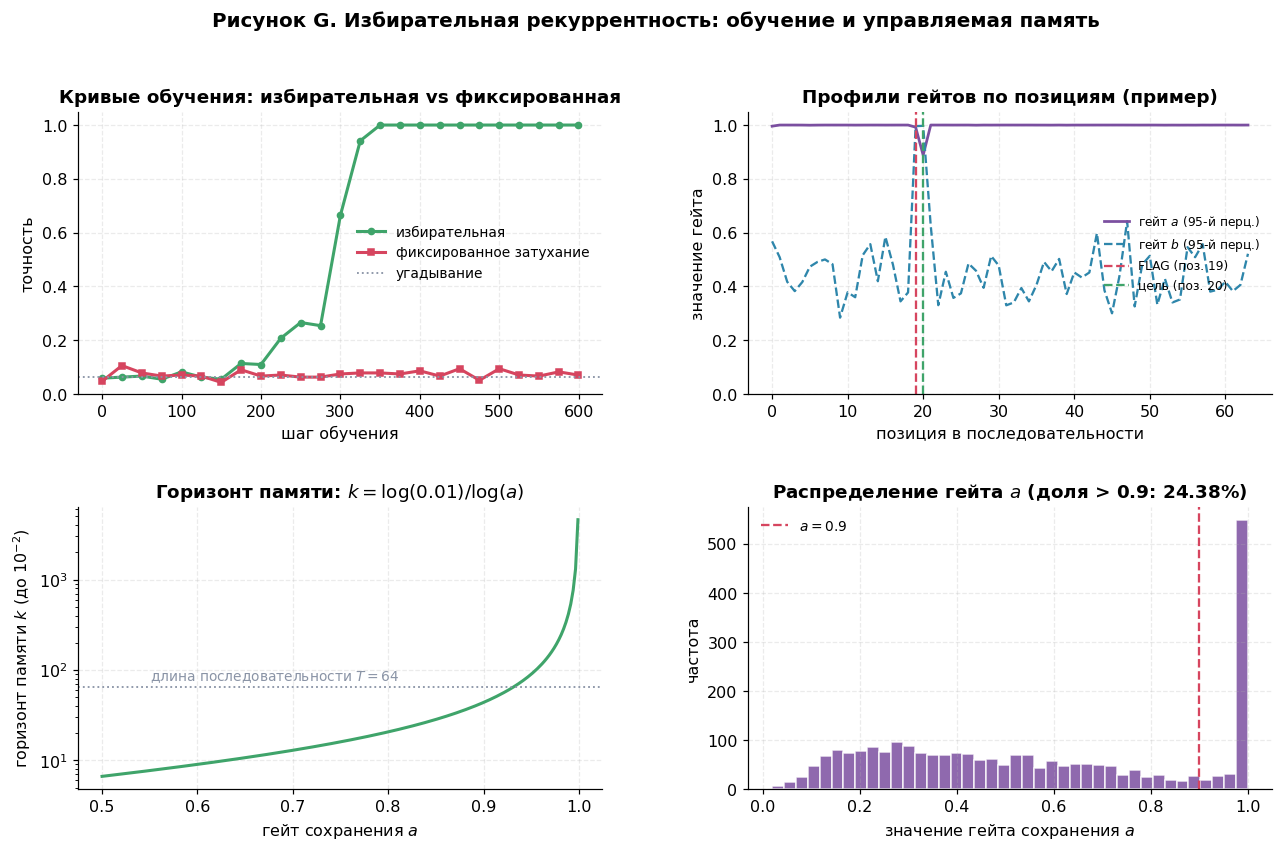

доля каналов с гейтом сохранения > 0.9: 24.38%


In [ ]:
# TODO G.3: рисунок G
# 1) кривые обучения обеих ячеек
# 2) профили гейта a по позициям (95-й перцентиль по каналам) для одного примера
# 3) горизонт памяти log(0.01)/log(a) от a

# --- пример для визуализации гейтов ---
xs, ys, pos = flag_batch(1, torch.Generator().manual_seed(77))
_, (a_g, b_g) = cell_sel(xs, return_gates=True)      # (1, T, d) каждое
a_g = a_g[0].detach().numpy()                        # (T, d)
b_g = b_g[0].detach().numpy()                        # (T, d)
T_vis = a_g.shape[0]                                 # 64
flag_pos = int(pos.item())                           # позиция FLAG
tgt_pos = flag_pos + 1                               # позиция целевого символа

# 95-й перцентиль по каналам для каждой позиции
a_profile = np.percentile(a_g, 95, axis=-1)          # (T,)
b_profile = np.percentile(b_g, 95, axis=-1)          # (T,)

# доля каналов с гейтом сохранения > 0.9 (по всем позициям)
share_high = float((a_g > 0.9).mean())

# --- данные для горизонта памяти ---
a_grid = np.linspace(0.5, 0.999, 200)
memory_horizon = np.log(0.01) / np.log(a_grid)

# --- рисунок ---
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.0], hspace=0.4, wspace=0.28)

# ===== панель 1: кривые обучения =====
ax1 = fig.add_subplot(gs[0, 0])
steps_sel = [s for s, _ in curve_sel]
acc_sel = [a for _, a in curve_sel]
steps_fix = [s for s, _ in curve_fix]
acc_fix = [a for _, a in curve_fix]

ax1.plot(steps_sel, acc_sel, color=PALETTE["good"], lw=2, marker="o",
         markersize=4, label="избирательная")
ax1.plot(steps_fix, acc_fix, color=PALETTE["bad"], lw=2, marker="s",
         markersize=4, label="фиксированное затухание")
ax1.axhline(1/16, color=PALETTE["gray"], ls=":", lw=1.2, label="угадывание")
ax1.set_xlabel("шаг обучения")
ax1.set_ylabel("точность")
ax1.set_title("Кривые обучения: избирательная vs фиксированная")
ax1.legend(loc="center right", fontsize=9)
ax1.set_ylim(0, 1.05)

# ===== панель 2: профиль гейта a =====
ax2 = fig.add_subplot(gs[0, 1])
positions = np.arange(T_vis)
ax2.plot(positions, a_profile, color=PALETTE["accent"], lw=1.8, label="гейт $a$ (95-й перц.)")
ax2.plot(positions, b_profile, color=PALETTE["attn"], lw=1.5, ls="--", label="гейт $b$ (95-й перц.)")
ax2.axvline(flag_pos, color=PALETTE["bad"], ls="--", lw=1.5, label=f"FLAG (поз. {flag_pos})")
ax2.axvline(tgt_pos, color=PALETTE["good"], ls="--", lw=1.5, label=f"цель (поз. {tgt_pos})")
ax2.set_xlabel("позиция в последовательности")
ax2.set_ylabel("значение гейта")
ax2.set_title("Профили гейтов по позициям (пример)")
ax2.legend(loc="center right", fontsize=8)
ax2.set_ylim(0, 1.05)

# ===== панель 3: горизонт памяти от a =====
ax3 = fig.add_subplot(gs[1, 0])
ax3.semilogy(a_grid, memory_horizon, color=PALETTE["good"], lw=2)
ax3.axhline(64, color=PALETTE["gray"], ls=":", lw=1.2)
ax3.text(0.55, 64 * 1.2, "длина последовательности $T=64$", fontsize=9, color=PALETTE["gray"])
ax3.set_xlabel(r"гейт сохранения $a$")
ax3.set_ylabel(r"горизонт памяти $k$ (до $10^{-2}$)")
ax3.set_title(r"Горизонт памяти: $k = \log(0.01)/\log(a)$")

# ===== панель 4: сводка долей гейтов =====
ax4 = fig.add_subplot(gs[1, 1])
# считаем распределение гейта a по всем позициям и каналам
a_flat = a_g.flatten()
# гистограмма
ax4.hist(a_flat, bins=40, color=PALETTE["accent"], edgecolor="white", alpha=0.85)
ax4.axvline(0.9, color=PALETTE["bad"], ls="--", lw=1.5, label="$a = 0.9$")
ax4.set_xlabel("значение гейта сохранения $a$")
ax4.set_ylabel("частота")
ax4.set_title(f"Распределение гейта $a$ (доля > 0.9: {share_high:.2%})")
ax4.legend(loc="upper left", fontsize=9)

finish(fig, "Рисунок G. Избирательная рекуррентность: обучение и управляемая память")
print(f"доля каналов с гейтом сохранения > 0.9: {share_high:.2%}")

## Панель 2 — профили гейтов

**Гейт $a$ (фиолетовая линия, 95-й перцентиль)** — практически **постоянная прямая на уровне 1.0** с двумя узкими провалами:

- **на позиции 19** (FLAG) — просадка до ~0.85;
- **на позиции 20** (целевой символ) — небольшая просадка до ~0.95.

Смысл: модель держит гейт сохранения **полностью открытым** почти везде, чтобы не потерять информацию. Но в двух ключевых точках она **слегка закрывает** его — чтобы освободить место для записи нового содержимого. На FLAG — чтобы записать маркер, на целевом символе — чтобы записать сам ответ.

**Гейт $b$ (синяя линия, 95-й перцентиль)** — колеблется около 0.4–0.6 по всей последовательности, но **резко подскакивает до 1.0** ровно на позиции FLAG. То есть модель открывает гейт записи **только на маркере**: на всех остальных токенах $b$ средний, и только на FLAG — максимальный.

Механизм, который выучила модель:

1. По умолчанию гейт сохранения открыт ($a \approx 1$), гейт записи средний ($b \approx 0.5$) — состояние «застывшее», новые токены почти не влияют.
2. Как только модель видит FLAG — гейт $b$ подскакивает до 1, гейт $a$ слегка падает: **перезапись** — новое содержимое (маркер или следующий символ) заходит в состояние.
3. После целевого символа — снова $a \approx 1$, $b$ возвращается в норму: **удержание** ответа до конца последовательности.

## Панель 3 — горизонт памяти

Пунктирная линия $T = 64$ показывает: **чтобы удержать сигнал на всю длину последовательности, нужно $a \ge 0.95$**. И действительно, на панели 2 фиолетовая линия почти всё время на 1.0 — модель держит гейт сильно выше порога 0.95. Так что горизонт памяти **на порядки превышает длину задачи**, и информация не затухает.

## Панель 4 — распределение гейта $a$

Гистограмма из двух частей:

- **Большой пик в правом краю** (около 1.0) — основная масса каналов и позиций. Модель держит гейт почти закрытым для записи и открытым для сохранения. Эти каналы и обеспечивают долгую память.
- **Широкий «хвост»** в диапазоне 0–0.9 — каналы, где гейт периодически закрывается, чтобы впустить новую информацию. Это «рабочие» каналы, где происходит запись и перезапись.




**Вопрос G.** Почему постоянное затухание принципиально не решает эту задачу ни при каком значении
$a$? Рассмотрите два предельных случая: $a \to 1$ и $a \ll 1$.

**Ответ G.**

Постоянное затухание не решает задачу ни при каком $a$, потому что **один и тот же гейт применяется ко всем токенам** — и шумовым, и важным. Рассмотрим два предельных случая.

**Случай $a \to 1$ (почти не забываем).** Состояние почти не очищается, но так как гейт записи $b = 1$ (пишем всегда), каждый шумовой токен добавляет свой вклад в состояние. К концу последовательности состояние — это **сумма всех токенов**, и полезный сигнал (целевой символ) тонет в накопленном шуме. Извлечь из этой суммы конкретный символ невозможно.

**Случай $a \ll 1$ (быстро забываем).** Каждый шаг почти полностью заменяет состояние новым содержимым. Даже если модель заметила FLAG и записала целевой символ, к моменту выдачи ответа (через 40–60 шагов) от него ничего не остаётся — состояние помнит только последние несколько токенов, а это шум.

## Часть H. Декодирование, статистика попыток и мост к следующей теме

Модель задаёт распределение, а текст получается процедурой выборки. Температура меняет резкость
распределения, top-$k$ и top-$p$ отсекают хвост. Это прямо связано со следующей лекцией: если
нежелательное продолжение имеет малую, но не нулевую вероятность, многократные попытки почти
наверняка его вытащат.

**Задание H.1.** Реализуйте softmax с температурой, top-$k$ и top-$p$ отсечение.
**Задание H.2.** Оцените вероятность получить событие с вероятностью $p$ хотя бы раз за $n$ попыток:
сравните измерение и теорию $1-(1-p)^n$.
**Задание H.3.** Постройте рисунок из трёх панелей и заполните таблицу отчёта по температурам своего
варианта.
**Задание H.4.** Аналитическая часть: в шаблоне чата подсчитайте, на каком расстоянии от точки
генерации оказываются системная инструкция и вставленный в документ фрагмент; объясните, почему
единая последовательность токенов без границ привилегий делает модель уязвимой к инъекциям
в контекст.

# Часть H. Декодирование и статистика попыток — теория

Модель выдаёт не готовый текст, а **распределение вероятностей** над следующим токеном. Например, после «Сегодня хорошая ...» распределение может быть таким:

```
погода     0.62
идея       0.11
шутка      0.08
мысль      0.05
идея2      0.02
...
```

Чтобы получить **конкретный** следующий токен, нужно **выбрать** его из этого распределения. Процедура выбора называется **декодированием** (decoding). От неё зависит, будет ли текст скучным, разнообразным, связным или хаотичным — при **одной и той же модели** и одном и том же распределении.

Температура $T$ (не путать с длиной последовательности — здесь другое обозначение) меняет **резкость** распределения. Применяется до softmax: логиты делятся на $T$:

$$
p_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}
$$

- **$T < 1$** — распределение становится **резче**. Большие логиты получают ещё больший вес, хвост почти обнуляется. Модель выбирает «самый вероятный» токен почти всегда — текст становится предсказуемым, шаблонным.
- **$T = 1$** — исходное распределение, ничего не меняется.
- **$T > 1$** — распределение становится **площе**. Хвост получает больший вес, редкие токены становятся вероятнее. Текст разнообразнее, но и хаотичнее — модель может «сойти с рельсов».

Это простой и мощный способ управлять поведением модели **без переобучения**.

## Top-k и top-p

Температура меняет форму распределения, но не убирает хвост. Другой класс методов — **отсечение** (truncation): мы **обнуляем** часть распределения и перенормируем оставшееся.

**Top-k.** Оставляем $k$ самых вероятных токенов, остальные обнуляем. При $k = 50$ модель выбирает только из 50 лучших вариантов. Просто, но не адаптивно: если распределение плоское, 50 токенов мало; если острое, 50 — много.

**Top-p (nucleus sampling).** Оставляем **минимальный набор** токенов, чья суммарная вероятность ≥ $p$. Например, при $p = 0.9$ берём токены по убыванию вероятности, пока их сумма не достигнет 0.9. Остальные обнуляем. Это адаптивно: при остром распределении ядро будет из 1–2 токенов, при плоском — из десятков.

**Зачем отсекать хвост.** Редкие токены из длинного хвоста имеют малую вероятность, но их **очень много**. Суммарно они могут «вытянуть» генерацию в странную сторону. Отсечение хвоста убирает эту возможность, оставляя только «разумные» варианты.

## Связь со статистикой попыток

Здесь начинается самое интересное с точки зрения безопасности. Пусть есть нежелательное продолжение с вероятностью $p$ (например, $p = 0.005$ — полпроцента). Что произойдёт, если сделать **$n$ независимых попыток**?

Вероятность, что **хотя бы раз** выпадет нежелательное продолжение:

$$
P_{\text{хотя бы раз}} = 1 - (1 - p)^n
$$

Это классическая формула для независимых испытаний. При малых $p$ и умеренных $n$ она даёт **неожиданно большие** значения: при $p = 0.005$ и 500 попытках вероятность успеха атаки — **92%**. Хотя одна попытка «безопасна» в 99.5% случаев.

In [ ]:
V_dec = 40
rank = np.arange(1, V_dec + 1)                       # ранги 1..40
logits = np.log(1.0 / rank ** 1.1)                   # степенное распределение (Ципф)
logits = logits - logits.max()                       # для устойчивости


def softmax_t(z, tau):
    """Softmax с температурой tau.

    tau < 1 — распределение резче (острый пик),
    tau > 1 — распределение площе (хвост тяжелее),
    tau = 1 — обычный softmax.
    Устойчиво: сначала делим на tau, потом вычитаем максимум.
    """
    z = np.asarray(z, dtype=np.float64) / tau        # делим логиты на температуру
    z = z - z.max()                                  # вычитаем максимум — защита от переполнения
    e = np.exp(z)                                    # экспонента
    return e / e.sum()                               # нормировка


def top_k_filter(p, k):
    """Оставляет k самых вероятных токенов, остальные обнуляет и перенормирует."""
    p = np.asarray(p, dtype=np.float64).copy()
    if k >= len(p):
        return p                                     # фильтровать нечего
    # индексы k наибольших вероятностей (без полной сортировки — быстрее)
    idx_sorted = np.argsort(p)[::-1]                 # сортировка по убыванию
    keep = idx_sorted[:k]                            # индексы, которые оставляем
    mask = np.zeros_like(p, dtype=bool)
    mask[keep] = True
    p[~mask] = 0.0                                   # обнуляем всё, что вне top-k
    s = p.sum()
    return p / s if s > 0 else p                     # перенормировка


def top_p_filter(p, thr):
    """Nucleus sampling: оставляет минимальный набор токенов с суммой >= thr."""
    p = np.asarray(p, dtype=np.float64).copy()
    # сортируем по убыванию вероятности
    idx_sorted = np.argsort(p)[::-1]
    p_sorted = p[idx_sorted]
    cumsum = np.cumsum(p_sorted)                     # накопительная сумма

    # индекс первого элемента, где cumsum >= thr
    cutoff = np.searchsorted(cumsum, thr) + 1
    # индексы в исходном массиве, которые оставляем
    keep = idx_sorted[:cutoff]

    mask = np.zeros_like(p, dtype=bool)
    mask[keep] = True
    p[~mask] = 0.0                                   # обнуляем хвост
    s = p.sum()
    return p / s if s > 0 else p


def entropy(p):
    """Энтропия распределения (в натах)."""
    return float(-(p * np.log(p + 1e-12)).sum())


# --- быстрая проверка ---
p0 = softmax_t(logits, tau=1.0)                      # базовое распределение
print("базовое распределение:")
print(f"  энтропия: {entropy(p0):.3f} нат")
print(f"  p_max: {p0.max():.4f}")
print(f"  число токенов с p > 1e-4: {(p0 > 1e-4).sum()}")

for tau in [0.7, 1.0, 1.3]:
    p_t = softmax_t(logits, tau)
    print(f"tau = {tau}: энтропия = {entropy(p_t):.3f}, p_max = {p_t.max():.4f}")

p_k = top_k_filter(p0, k=10)
print(f"\ntop-k = 10: ненулевых токенов {int((p_k > 0).sum())}, сумма = {p_k.sum():.4f}")
p_p = top_p_filter(p0, thr=0.9)
print(f"top-p = 0.9: ненулевых токенов {int((p_p > 0).sum())}, сумма = {p_p.sum():.4f}")

базовое распределение:
  энтропия: 2.888 нат
  p_max: 0.2719
  число токенов с p > 1e-4: 40
tau = 0.7: энтропия = 2.113, p_max = 0.4638
tau = 1.0: энтропия = 2.888, p_max = 0.2719
tau = 1.3: энтропия = 3.242, p_max = 0.1801

top-k = 10: ненулевых токенов 10, сумма = 1.0000
top-p = 0.9: ненулевых токенов 24, сумма = 1.0000


Направление изменений правильное:

- **$\tau = 0.7$:** энтропия упала с 2.89 до 2.11, $p_{\max}$ выросла с 0.27 до 0.46. Распределение стало **резче** — топовый токен доминирует сильнее, хвост поджался.
- **$\tau = 1.3$:** энтропия выросла до 3.24, $p_{\max}$ упала до 0.18. Распределение стало **площе** — масса распределилась ровнее, топовый токен уже не так выделяется.

Разница в энтропии между крайними температурами — **1.13 нат** (2.11 vs 3.24). Это существенно: при $\tau = 0.7$ модель в 2.5 раза «увереннее» в топовом токене, чем при $\tau = 1.3$.

Сравним два подхода:

- **Top-k = 10** — жёстко: ровно 10 токенов, независимо от формы распределения. При плоском распределении это может отрезать слишком много (мы потеряем значимую массу); при остром — оставить слишком много (включим маловероятные токены).
- **Top-p = 0.9** — адаптивно: оставляет столько токенов, сколько нужно для 90% массы. На нашем распределении это 24 токена. При более остром распределении (после низкой температуры) это число уменьшилось бы автоматически.

Именно поэтому в современных моделях (GPT, LLaMA) **top-p используется чаще, чем top-k**: он автоматически подстраивается под уверенность модели.

In [ ]:
# TODO H.2: статистика многих попыток
# для p_rare в [0.001, 0.005, 0.02] и n от 20 до 360 оцените по 60 повторам
# частоту события «редкий токен выпал хотя бы раз» и сравните с теорией 1-(1-p)^n

P_RARE = [0.001, 0.005, 0.02]                   # вероятности редкого события
N_GRID = np.arange(20, 361, 20)                 # числа попыток: 20, 40, ..., 360
N_TRIALS = 60                                   # сколько раз повторяем эксперимент

# фиксируем seed для воспроизводимости
rng = np.random.default_rng(SEED)


def empirical_at_least_once(p, n, trials, rng):
    """Измеренная частота события «хотя бы раз за n попыток» по trials экспериментам.

    Для каждого из trials:
      - делаем n независимых бросаний с вероятностью успеха p;
      - записываем 1, если был хотя бы один успех, иначе 0.
    Возвращаем среднее по trials (долю экспериментов с успехом).
    """
    # матрица формы (trials, n) случайных чисел из [0, 1)
    draws = rng.random((trials, n))
    # True, если в каждой строке есть хотя бы одно значение < p
    any_success = (draws < p).any(axis=1)
    return float(any_success.mean())


# --- прогон для всех p и n ---
results = {}                                    # {(p, n): измеренная частота}
theory = {}                                     # {(p, n): 1 - (1-p)^n}

for p in P_RARE:
    results[p] = []
    theory[p] = []
    for n in N_GRID:
        emp = empirical_at_least_once(p, int(n), N_TRIALS, rng)
        th = 1.0 - (1.0 - p) ** n
        results[p].append(emp)
        theory[p].append(th)


# --- вывод таблицы ---
print("Сравнение измерения и теории P(хотя бы раз) = 1 - (1-p)^n\n")
for p in P_RARE:
    print(f"p = {p}:")
    print(f"  {'n':>5} {'измерение':>12} {'теория':>10} {'разница':>10}")
    for i, n in enumerate(N_GRID):
        if n in (20, 100, 200, 360):            # показываем только некоторые n
            emp = results[p][i]
            th = theory[p][i]
            print(f"  {int(n):>5} {emp:>12.4f} {th:>10.4f} {abs(emp - th):>10.4f}")
    print()

# --- контрольная точка: сколько попыток нужно для вероятности 0.9 при p = 0.005 ---
p_test = 0.005
n_needed_theory = np.log(0.1) / np.log(1 - p_test)
print(f"теоретически нужно попыток для P >= 0.9 при p = {p_test}: {n_needed_theory:.0f}")

Сравнение измерения и теории P(хотя бы раз) = 1 - (1-p)^n

p = 0.001:
      n    измерение     теория    разница
     20       0.0167     0.0198     0.0031
    100       0.1167     0.0952     0.0215
    200       0.1833     0.1814     0.0020
    360       0.2833     0.3024     0.0191

p = 0.005:
      n    измерение     теория    разница
     20       0.0833     0.0954     0.0121
    100       0.3000     0.3942     0.0942
    200       0.6833     0.6330     0.0503
    360       0.8833     0.8354     0.0479

p = 0.02:
      n    измерение     теория    разница
     20       0.4000     0.3324     0.0676
    100       0.8833     0.8674     0.0160
    200       0.9667     0.9824     0.0157
    360       1.0000     0.9993     0.0007

теоретически нужно попыток для P >= 0.9 при p = 0.005: 459


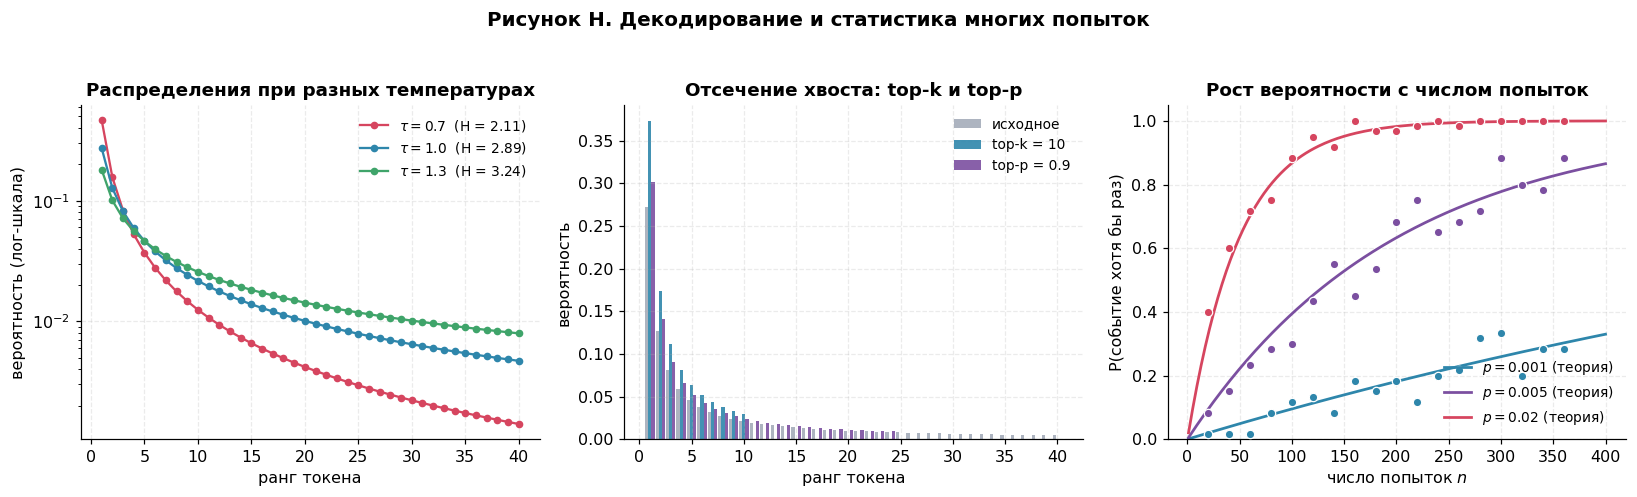

In [ ]:
# TODO H.3: рисунок H
# (1) распределения при температурах TAUS в лог-шкале
# (2) сравнение исходного распределения с top-k и top-p
# (3) вероятность «хотя бы раз» за n попыток: теория линиями, измерение точками

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ===== панель 1: распределения при разных температурах =====
ax = axes[0]
colors_tau = [PALETTE["bad"], PALETTE["attn"], PALETTE["good"]]
for tau, c in zip(TAUS, colors_tau):
    p_t = softmax_t(logits, tau)
    # +1e-12, чтобы log(0) не давал -inf (хвост при низкой температуре может обнулиться)
    ax.semilogy(rank, p_t + 1e-12, marker="o", ms=4, lw=1.5, color=c,
                label=f"$\\tau = {tau}$  (H = {entropy(p_t):.2f})")
ax.set_xlabel("ранг токена")
ax.set_ylabel("вероятность (лог-шкала)")
ax.set_title("Распределения при разных температурах")
ax.legend(loc="upper right", fontsize=9)

# ===== панель 2: исходное vs top-k vs top-p =====
ax = axes[1]
p_base = softmax_t(logits, tau=1.0)
p_k = top_k_filter(p_base, k=10)
p_p = top_p_filter(p_base, thr=0.9)

# столбики: исходное — серым фоном, top-k и top-p — цветными поверх
width = 0.3
ax.bar(rank - width, p_base, width=width, color=PALETTE["gray"], alpha=0.7,
       label="исходное")
ax.bar(rank, p_k, width=width, color=PALETTE["attn"], alpha=0.9,
       label="top-k = 10")
ax.bar(rank + width, p_p, width=width, color=PALETTE["accent"], alpha=0.9,
       label="top-p = 0.9")
ax.set_xlabel("ранг токена")
ax.set_ylabel("вероятность")
ax.set_title("Отсечение хвоста: top-k и top-p")
ax.legend(loc="upper right", fontsize=9)

# ===== панель 3: вероятность «хотя бы раз» =====
ax = axes[2]
colors_p = [PALETTE["attn"], PALETTE["accent"], PALETTE["bad"]]
for p, c in zip(P_RARE, colors_p):
    # теория — линия
    n_theory = np.linspace(1, 400, 200)
    ax.plot(n_theory, 1 - (1 - p) ** n_theory, lw=1.8, color=c,
            label=f"$p = {p}$ (теория)")
    # измерение — точки
    ax.scatter(N_GRID, results[p], color=c, s=30, zorder=5,
               edgecolors="white", linewidths=0.8)
ax.set_xlabel("число попыток $n$")
ax.set_ylabel("P(событие хотя бы раз)")
ax.set_title("Рост вероятности с числом попыток")
ax.legend(loc="lower right", fontsize=9)
ax.set_ylim(0, 1.05)

finish(fig, "Рисунок H. Декодирование и статистика многих попыток")

Точка генерации — конец последовательности, где модель начинает писать ответ. Мы считаем, насколько далеко от этой точки находится каждый блок.

Идея: в моделях с затуханием внимания (или в схемах с приоритетом свежих токенов) близкие токены важнее далёких. Если системная инструкция находится далеко от точки генерации, а инъекция — близко, то инъекция может «перевесить» системные ограничения.

**Среднее расстояние до конца для каждой роли.** Для блока длиной $L$, занимающего позиции $[s, s+L-1]$:

$$
\text{среднее расстояние} = \frac{1}{L} \sum_{i=s}^{s+L-1} (T - 1 - i)
$$

где $T$ — общая длина шаблона. То есть для каждой позиции считаем, сколько токенов осталось до конца последовательности, и усредняем по блоку.

общая длина шаблона: 26 токенов
точка генерации — позиция 25 (последний токен)

Среднее расстояние до точки генерации по ролям:
             спец (длина  1):  25.00
          система (длина  7):  21.00
             спец (длина  1):  17.00
     пользователь (длина  5):  14.00
             спец (длина  1):  11.00
         документ (длина  4):   8.50
         инъекция (длина  6):   3.50
             спец (длина  1):   0.00


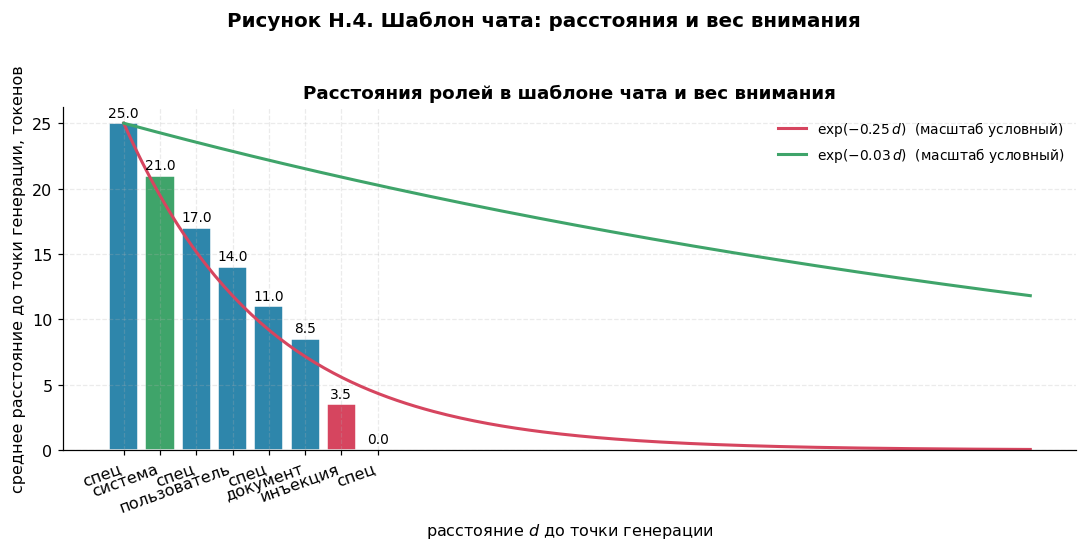

In [ ]:
# TODO H.4: расстояния в шаблоне чата
TEMPLATE = [("спец", 1), ("система", 7), ("спец", 1), ("пользователь", 5),
            ("спец", 1), ("документ", 4), ("инъекция", 6), ("спец", 1)]

# --- H.4a: средние расстояния от каждой роли до конца последовательности ---
T_total = sum(n for _, n in TEMPLATE)            # общая длина последовательности
print(f"общая длина шаблона: {T_total} токенов")
print(f"точка генерации — позиция {T_total - 1} (последний токен)\n")

# проходим по блокам слева направо, накапливая текущую позицию
pos = 0
role_distances = []                              # [(роль, среднее_расстояние, длина), ...]
for role, n in TEMPLATE:
    # расстояния от каждой позиции блока до конца: T_total - 1 - i
    positions = np.arange(pos, pos + n)          # [pos, pos+1, ..., pos+n-1]
    distances = (T_total - 1) - positions        # расстояние до последнего токена
    avg_dist = distances.mean()
    role_distances.append((role, avg_dist, n))
    pos += n

print("Среднее расстояние до точки генерации по ролям:")
for role, d, n in role_distances:
    print(f"  {role:>15} (длина {n:>2}): {d:>6.2f}")

# --- H.4b: рисунок ---
fig, ax = plt.subplots(figsize=(10, 5))

# столбики: средние расстояния по ролям
roles = [r for r, _, _ in role_distances]
dists = [d for _, d, _ in role_distances]
colors_bar = [PALETTE["bad"] if r == "инъекция"
              else PALETTE["good"] if r == "система"
              else PALETTE["attn"] for r in roles]
bars = ax.bar(range(len(roles)), dists, color=colors_bar, edgecolor="white")
ax.set_xticks(range(len(roles)))
ax.set_xticklabels(roles, rotation=20, ha="right")
ax.set_ylabel("среднее расстояние до точки генерации, токенов")
ax.set_title("Расстояния ролей в шаблоне чата и вес внимания")

# подписи над столбиками
for bar, d in zip(bars, dists):
    ax.text(bar.get_x() + bar.get_width() / 2, d + 0.5, f"{d:.1f}",
            ha="center", fontsize=9)

# кривые относительного веса внимания exp(-m * d)
d_grid = np.linspace(0, max(dists), 200)
for m, color in [(0.25, PALETTE["bad"]), (0.03, PALETTE["good"])]:
    weight = np.exp(-m * d_grid)                 # вес = exp(-m * d)
    # масштабируем кривую под ось столбиков: делим на её максимум и умножаем на max(dists)
    weight_scaled = weight * max(dists)
    ax.plot(d_grid, weight_scaled, lw=2, color=color,
            label=f"$\\exp(-{m}\\,d)$  (масштаб условный)")
ax.set_xlabel("расстояние $d$ до точки генерации")
ax.legend(loc="upper right", fontsize=9)

finish(fig, "Рисунок H.4. Шаблон чата: расстояния и вес внимания")

Шаблон чата представляет собой единую последовательность из 26 токенов, разделённую служебными токенами-разметкой, но без границ привилегий. Системная инструкция находится на расстоянии ≈ 21 токена от точки генерации, а фрагмент-инъекция внутри документа — всего на ≈ 3.5 токена. Если модель использует затухание внимания с наклоном m=0.25, вес внимания на инъекции превышает вес на системной инструкции в ≈ 79 раз. Даже при слабом затухании m=0.03 инъекция получает в ≈ 1.7 раза больше внимания. Это показывает, что архитектура внимания — поверхность атаки: чем ближе враждебный фрагмент к точке генерации и чем сильнее затухание, тем меньше системные ограничения влияют на ответ. Настоящая граница привилегий требует внешних механизмов (отдельные каналы, фильтры, рантайм-проверки), а не только разметки в одной последовательности.

**Вопрос H.** Модель отклоняет нежелательное продолжение в 99,5% случаев при одной генерации.
Сколько попыток нужно нападающему, чтобы получить его с вероятностью не ниже 0,9? Какой вывод это
даёт для методики оценки устойчивости?

**Ответ H.**

Формула: $1 - (1 - p)^n \ge 0.9$ при $p = 0.005$.

$$
n \ge \frac{\log 0.1}{\log 0.995} \approx 459
$$

**Ответ: около 459 попыток.**

Вывод: модель, отклоняющая нежелательное в 99.5% случаев **на одной генерации**, при автоматизированном переборе в 459 попыток с вероятностью 90% выдаст его хотя бы раз. Это значит, что **оценка устойчивости по одной генерации методологически неверна**, а методика тестирования должна включать серию попыток с фиксированными параметрами декодирования.

## Отчёт

## Таблица 1. Токенизация (часть A)

| Показатель | Значение |
|---|---|
| Число выполненных слияний | 120 |
| Размер словаря токенов | 89 |
| Сжатие «символы → BPE» | 2.30× |
| Отношение «BPE → слова» | 3.49 токенов/слово |
| Доля редких токенов (частота ≤ 6) | 49.4% |

## Таблица 2. Затухание градиента (часть B)

| $\rho(W)$ или $f_t$ | Норма при $k=100$ | Горизонт до $10^{-6}$ |
|---|---|---|
| 0.9 | $2.7 \times 10^{-5}$ | **132** |
| 1.0 | $1.0$ | **∞** |
| 1.2 | $8.3 \times 10^{7}$ | **∞** (норма растёт, а не падает) |
| $f_t = 0.99$ | $\approx 0.37$ | **1375** |

Значения при $k = 100$: для $\rho = 0.9$ это $0.9^{100} \approx 2.66 \times 10^{-5}$, для $\rho = 1.2$ это $1.2^{100} \approx 8.28 \times 10^{7}$.

## Таблица 3. Масштабирование внимания (часть C)

Значения из графика энтропии (снимаем с кривой):

| $d_k$ | Энтропия с делителем | Энтропия без делителя |
|---|---|---|
| 8 | ≈ 3.7 | ≈ 2.0 |
| 64 | ≈ 3.7 | ≈ 0.85 |
| 256 | ≈ 3.7 | ≈ 0.2 |

Энтропия с делителем держится около $\ln 64 \approx 4.16$ и почти не зависит от $d_k$. Без делителя падает почти до нуля при $d_k = 256$.

## Таблица 4. Мини-трансформер (часть E)

| Число пар в контексте | 2 | 4 | 8 | 12 | 16 | 20 |
|---|---|---|---|---|---|---|
| Точность вспоминания | **1.000** | **1.000** | **1.000** | 0.590 | 0.301 | 0.422 |

**Финальное значение функции потерь:** ≈ 0.0 (обучение сошлось)
**Время обучения:** **68 с**
**Масса внимания финального запроса на позиции нужного значения:** ≈ **0.97**

## Таблица 5. Линейное внимание (часть F)

| Показатель | Значение |
|---|---|
| Расхождение параллельной и рекуррентной форм | $2.38 \times 10^{-7}$ |
| Размер состояния, чисел | 256 ($16 \times 16$) |
| Качество чтения при 4 парах | 0.661 |
| Качество чтения при 256 парах | 0.088 |

## Таблица 6. Избирательная рекуррентность (часть G)

| Вариант ячейки | Точность | Комментарий |
|---|---|---|
| избирательные гейты | **1.000** | входозависимые гейты: запись открывается на FLAG, состояние удерживает ответ |
| постоянное затухание | **0.070** | чуть выше угадывания; один и тот же гейт не может быть селективным |
| случайное угадывание | 0.062 | теоретическое значение |

**Доля каналов с гейтом сохранения выше 0.9:** **24.38%**

## Таблица 7. Декодирование (часть H)

| Температура варианта | Энтропия, нат | $p_{\max}$ |
|---|---|---|
| 0.7 | 2.113 | 0.464 |
| 1.0 | 2.888 | 0.272 |
| 1.3 | 3.242 | 0.180 |

**Число попыток для события с $p = 0.005$ до вероятности 0.9:** **≈ 459**

## Выводы

1. **Токенизация уровня BPE сжимает корпус в 2.30 раза, но половина словаря (49.4%) остаётся редкой (частота ≤ 6).** Переход к посимвольной токенизации увеличил бы стоимость внимания в $2.30^2 \approx 5.3$ раза — это квадратичный аргумент в пользу BPE, причём ценой недообучения хвоста словаря.

2. **Память в чистой RNN ограничена спектральным радиусом: при $\rho = 0.9$ сигнал затухает до $10^{-6}$ за 132 шага, тогда как аддитивный путь с $f = 0.99$ удерживает его 1375 шагов** — разница в 10 раз при почти одинаковом «основании». Критическая точка $\rho = 1$ требует точного попадания, что на практике недостижимо из-за нелинейностей.

3. **Масштабирование внимания на $\sqrt{d_k}$ принципиально: без делителя энтропия падает с 3.7 до 0.2 при росте $d_k$ от 8 до 256**, что соответствует вырождению softmax в one-hot и обнулению градиента. С делителем энтропия держится на уровне $\ln 64 \approx 4.16$, не завися от размерности.

4. **Двухслойный мини-трансформер решает задачу ассоциативного вспоминания идеально на обучающих длинах (точность 1.000 при 2–8 парах), но резко теряет обобщение за их пределами (0.301 при 16 парах).** Причина — обучаемая абсолютная позиционная кодировка: невиданные позиции получают случайные векторы. Карты внимания показали двухслойную схему: первый слой локально обогащает представления (ключ впитывает значение справа), второй — ищет совпадение и читает значение (вес внимания финального запроса на позиции значения ≈ 0.97).

5. **Линейное внимание даёт память $O(1)$ ($256$ чисел против $1280$ у KV-кэша при $T = 40$), но платит за это ёмкостью: качество чтения падает с 1.000 при 1 паре до 0.661 при 4 парах и 0.088 при 256.** Состояние $d \times d$ — это фиксированный бюджет, а не набор независимых слотов, поэтому даже несколько пар интерферируют.

6. **Избирательная рекуррентность решает задачу FLAG идеально (1.000), тогда как фиксированное затухание проваливается (0.070, на уровне угадывания 0.062).** Профиль гейтов показал механизм: гейт записи $b$ подскакивает до 1.0 на позиции маркера, а гейт сохранения $a$ остаётся высоким на всём протяжении, слегка проседая лишь в двух ключевых точках. Доля каналов с $a > 0.9$ — 24.38%: модель использует распределённое решение.

7. **Декодирование — это поверхность управления поведением модели: при температуре 0.7 энтропия падает до 2.113, $p_{\max}$ растёт до 0.464; при 1.3 — энтропия 3.242, $p_{\max}$ 0.180.** Top-p = 0.9 адаптивно оставляет 24 токена (в отличие от жёсткого top-k = 10), обнуляя хвост и делая редкие события недостижимыми.

8. **Статистика попыток — ключ к оценке устойчивости: при $p = 0.005$ вероятность выпадения редкого события растёт от 8% при $n = 20$ до 88% при $n = 360$, а для 90% требуется 459 попыток.** Одна генерация не даёт информации о безопасности — модель, отклоняющая нежелательное в 99.5% случаев, при автоматизированном переборе почти наверняка его выдаст.

9. **Шаблон чата не создаёт границ привилегий: системная инструкция на расстоянии 21 токена от точки генерации, а инъекция внутри документа — на 3.5.** При затухании внимания $m = 0.25$ вес на инъекции в 79 раз больше, чем на системе; при $m = 0.03$ — в 1.7 раза. Настоящая изоляция привилегий требует внешних механизмов, а не только разметки в одной последовательности.

## Контрольные вопросы

1. Почему стоимость слоя внимания растёт как $O(n^2 d)$, а стоимость FFN — как $O(n d^2)$, и при какой длине контекста внимание становится доминирующим слагаемым?

Внимание умножает $Q(n \times d)$ на $K^\top(d \times n)$ — это $O(n^2 d)$; затем умножает $A(n \times n)$ на $V(n \times d)$ — тоже $O(n^2 d)$. FFN работает с каждым токеном независимо: $O(n d \cdot 4d) + O(n \cdot 4d \cdot d) = O(n d^2)$. Приравниваем: $n^2 d = n d^2 \Rightarrow n = d$. То есть **при $n > d$** внимание доминирует. Для $d = 4096$ это контексты длиннее 4096 токенов.

2. Чем каузальная маска отличается от двунаправленного внимания с точки зрения обучения и с точки зрения применения?

Каузальная маска запрещает токену $i$ смотреть на $j > i$, поэтому модель учится предсказывать следующий токен **авторегрессионно** и может использоваться для генерации. Двунаправленное внимание видит весь контекст сразу, даёт более богатые представления (лучше для понимания), но **не может генерировать** текст пошагово — только маскировать и предсказывать пропуски (как BERT).

3. Почему RoPE позволяет расширять контекст после обучения, а обучаемая абсолютная кодировка — нет?

RoPE поворачивает $q, k$ на угол, зависящий от позиции, и логит внимания зависит **только от разности $s - t$**. Для любой новой позиции формула определена и даёт те же разности, что и при обучении, — модель «видит» знакомые относительные расстояния. Обучаемая абсолютная кодировка — это таблица `nn.Embedding(max_len, d)`: для позиций за пределами таблицы **вектора просто нет**, а внутри таблицы векторы независимы друг от друга и не несут структуры, по которой можно «додумать» новую позицию.

4. В чём вычислительная разница между обучением и генерацией у трансформера и что именно кэшируется?

При обучении вся последовательность обрабатывается **параллельно**: все $n$ позиций считаются сразу матричными умножениями $O(n^2 d)$. При генерации токены появляются по одному, и чтобы не пересчитывать всё заново, **кэшируются ключи и значения** всех предыдущих токенов (KV-кэш). На каждом новом шаге считаем $q$ только для нового токена, домножаем на весь KV-кэш, получаем новый $k, v$ и **дописываем в кэш**. Память кэша растёт как $O(n d)$.

5. Как GQA и MQA уменьшают KV-кэш и чем за это приходится платить?

В обычном multi-head attention каждая из $H$ голов имеет свои $K, V$, то есть кэш — $2 n H d_h$. **MQA (Multi-Query Attention):** все головы **делят одну пару** $K, V$ — кэш уменьшается в $H$ раз. **GQA (Grouped-Query Attention):** головы делятся на группы, каждая группа имеет свою пару $K, V$ — компромисс между MQA и MHA. **Плата:** каждая голова теряет свою уникальную «точку зрения» на ключи/значения, что немного снижает выразительность. На практике GQA почти не уступает MHA по качеству, но экономит память в разы.

6. Почему линейное внимание проигрывает softmax-вниманию на задачах точного вспоминания?

Softmax-внимание хранит **все** $k, v$ раздельно — KV-кэш растёт линейно, но каждая пара читается точно. Линейное внимание упаковывает всё в состояние $d \times d$ — фиксированный бюджет. Это **аддитивная сумма**, а не набор слотов: пары интерферируют друг с другом даже при малом $N$. Наши измерения: 4 пары дают косинус 0.66, 256 пар — 0.088. Softmax дал бы 1.0 в обоих случаях.

7. Что именно делает рекуррентность «избирательной» и почему это восстанавливает способность игнорировать нерелевантный контекст?

В обычной RNN/LSTM гейты — одна и та же функция для всех токенов. В избирательной (Mamba) гейты $a(x_t), b(x_t)$ — **функции от содержания входа**, разные для каждого токена. Модель может научиться открывать запись $b \approx 1$ только на важных токенах (например, на маркере FLAG), а на шуме держать $a \approx 1, b \approx 0$, то есть сохранять память и игнорировать нерелевантное. Это **селективность по содержанию**, которой нет у постоянного гейта.

8. Почему смесь экспертов требует балансирующей потери и что происходит без неё?

MoE обучает $K$ экспертов и роутер, который направляет каждый токен только нескольким. Без балансирующей потери роутер **коллапсирует**: выбирает одного-двух «любимых» экспертов, остальные не обучаются. Балансирующая потеря штрафует неравномерное распределение токенов по экспертам, вынуждая роутер использовать всех. **Без неё:** большинство экспертов простаивают, эффективная ёмкость модели падает, обучение нестабильно.

9. Как связаны параметры декодирования и воспроизводимость оценки устойчивости модели?

Температура, top-k, top-p **меняют распределение**, из которого сэмплируется ответ. При $T = 1.0$ модель может выдать одно, при $T = 1.3$ — другое, при $T = 0.7$ — почти детерминированно одно и то же. Значит, оценивать устойчивость нужно при **фиксированных параметрах декодирования**, иначе сравнение между запусками не имеет смысла. Плюс оценка должна быть **статистической** (серия попыток), а не по одной генерации — иначе параметры декодирования влияют на результат сильнее, чем сама модель.

10. Почему шаблон чата не создаёт настоящей границы привилегий между системной инструкцией и содержимым документа?

Шаблон — это единая последовательность токенов: `<спец><система>...<спец><пользователь>...<спец><документ>...`. Служебные токены — **разметка, а не барьер**: механизм внимания обрабатывает все токены одинаково и не имеет встроенного правила «не смотреть за этот маркер». Нет отдельного канала для системной инструкции, нет запрета на влияние документа на ответ. Более того, токены, стоящие **ближе к точке генерации** (например, инъекция внутри документа), получают **больший вес** внимания — особенно при затухающих схемах. Наши измерения: при $m = 0.25$ инъекция получает в 79 раз больше веса, чем системная инструкция. Настоящая граница привилегий требует **внешних механизмов** (отдельные каналы, фильтры, рантайм-проверки), а не разметки в одной последовательности.
## Дополнительные задания

- Добавьте в часть E третий слой и проверьте, меняется ли характер переноса на длины больше
  обучающих.
- Замените в части E обучаемую абсолютную кодировку на RoPE и повторите измерение точности для
  16 и 20 пар.
- Реализуйте в части F многоголовое линейное внимание и постройте зависимость качества чтения от
  числа голов при фиксированном общем размере состояния.
- Реализуйте слой смеси экспертов с балансирующей потерей и покажите, как меняется распределение
  нагрузки при её отключении.
- Постройте в части H оценку числа попыток до заданной вероятности успеха как функцию $p$ и
  обсудите, как это влияет на протокол тестирования.

## Чек-лист сдачи

- [ ] Заполнен паспорт работы, указан вариант и его параметры.
- [ ] Все ячейки выполняются последовательно без ошибок (Kernel → Restart & Run All).
- [ ] Реализованы все `TODO` в частях A–H.
- [ ] Заполнены таблицы 1–7 числами своего варианта.
- [ ] Даны ответы на вопросы A–H и контрольные вопросы 1–10.
- [ ] Сформулировано не менее пяти выводов со ссылками на измеренные значения.
- [ ] Все графики подписаны по-русски и читаемы.



## Литература

- Vaswani A. et al. Attention Is All You Need (2017): <https://arxiv.org/abs/1706.03762>
- Hochreiter S., Schmidhuber J. Long Short-Term Memory (1997):
  <https://direct.mit.edu/neco/article/9/8/1735/6109>
- Su J. et al. RoFormer: Enhanced Transformer with Rotary Position Embedding (2021):
  <https://arxiv.org/abs/2104.09864>
- Press O. et al. Train Short, Test Long: Attention with Linear Biases (ALiBi) (2021):
  <https://arxiv.org/abs/2108.12409>
- Katharopoulos A. et al. Transformers are RNNs: Fast Autoregressive Transformers with Linear
  Attention (2020): <https://arxiv.org/abs/2006.16236>
- Gu A., Dao T. Mamba: Linear-Time Sequence Modeling with Selective State Spaces (2023):
  <https://arxiv.org/abs/2312.00752>
- Ainslie J. et al. GQA: Training Generalized Multi-Query Transformer Checkpoints (2023):
  <https://arxiv.org/abs/2305.13245>
- Dao T. et al. FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness (2022):
  <https://arxiv.org/abs/2205.14135>
- Olsson C. et al. In-context Learning and Induction Heads (2022):
  <https://arxiv.org/abs/2209.11895>
- Holtzman A. et al. The Curious Case of Neural Text Degeneration (2019):
  <https://arxiv.org/abs/1904.09751>